In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set plotting style
sns.set_style("whitegrid")

# --- 1. Load Data ---
DATA_FILE = '../data/ipdr_synthetic_fixed.csv' # Use your file path
TARGET_COLUMN = 'anomaly_type'
DROP_COLUMNS = ['event_id', 'user_id', 'imsi', 'imei', 'runbook_id'] 

try:
    df_raw = pd.read_csv(DATA_FILE)
    print(f"Successfully loaded {len(df_raw)} rows.")
except FileNotFoundError:
    print(f"Error: Data file not found at {DATA_FILE}")

# --- 2. Minimal Cleaning for EDA ---
# Drop ID columns
df_v3_eda = df_raw.drop(columns=DROP_COLUMNS, errors='ignore')

# Fill target NaN values so we can plot them
# We create a new 'anomaly_name' column for our readable plots
df_v3_eda['anomaly_name'] = df_v3_eda[TARGET_COLUMN].fillna('Normal')

# --- 3. Initial Inspection ---
print("\n--- df.info() ---")
df_v3_eda.info()

print("\n--- df.describe() (Numerical Features) ---")
# Get stats for numerical columns
print(df_v3_eda.describe())

print("\n--- df.head() ---")
print(df_v3_eda.head())

Successfully loaded 78086 rows.

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78086 entries, 0 to 78085
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   timestamp       78086 non-null  object 
 1   domain          78086 non-null  object 
 2   ip_src          78086 non-null  object 
 3   ip_dst          78086 non-null  object 
 4   port            78086 non-null  int64  
 5   protocol        78086 non-null  object 
 6   duration        78086 non-null  float64
 7   bytes_sent      78086 non-null  int64  
 8   bytes_received  78086 non-null  int64  
 9   vpn_usage       78086 non-null  bool   
 10  cell_id         78086 non-null  object 
 11  location_lat    78086 non-null  float64
 12  location_lon    78086 non-null  float64
 13  is_fraud        78086 non-null  int64  
 14  anomaly_type    6246 non-null   object 
 15  anomaly_name    78086 non-null  object 
dtypes: bool(1), float64(3), i

--- 1. Target Variable Distribution ---


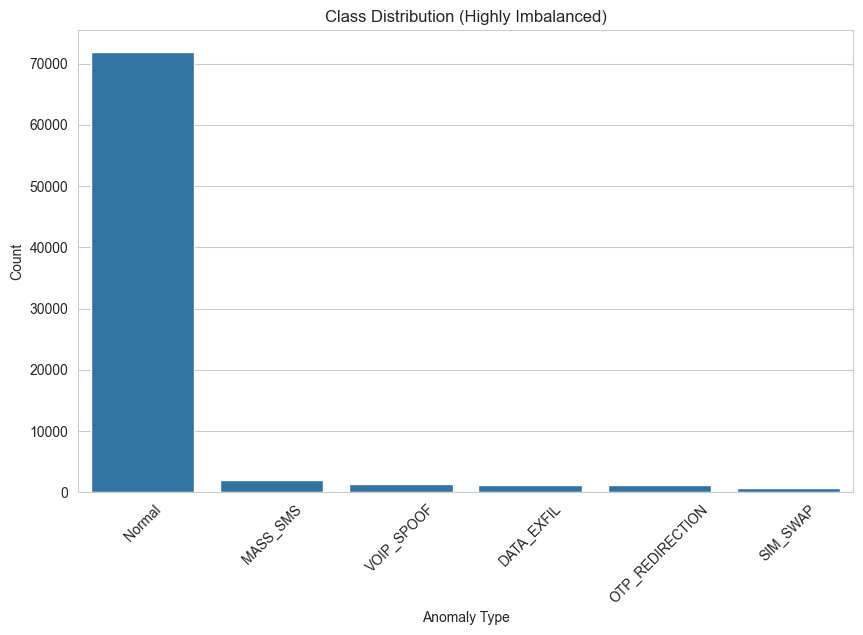

Class Counts:
anomaly_name
Normal             71840
MASS_SMS            2026
VOIP_SPOOF          1287
DATA_EXFIL          1121
OTP_REDIRECTION     1117
SIM_SWAP             695
Name: count, dtype: int64

Class Percentages:
anomaly_name
Normal             92.001127
MASS_SMS            2.594575
VOIP_SPOOF          1.648183
DATA_EXFIL          1.435597
OTP_REDIRECTION     1.430474
SIM_SWAP            0.890044
Name: proportion, dtype: float64


In [2]:
print("--- 1. Target Variable Distribution ---")

plt.figure(figsize=(10, 6))
# We use df_eda['anomaly_name'] which has 'Normal' filled in
sns.countplot(
    data=df_v3_eda,
    x='anomaly_name',
    order=df_v3_eda['anomaly_name'].value_counts().index
)
plt.title("Class Distribution (Highly Imbalanced)")
plt.xlabel("Anomaly Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Print the exact numbers
print("Class Counts:")
print(df_v3_eda['anomaly_name'].value_counts())
print("\nClass Percentages:")
print(df_v3_eda['anomaly_name'].value_counts(normalize=True) * 100)

--- 2. Numerical Feature Distributions ---


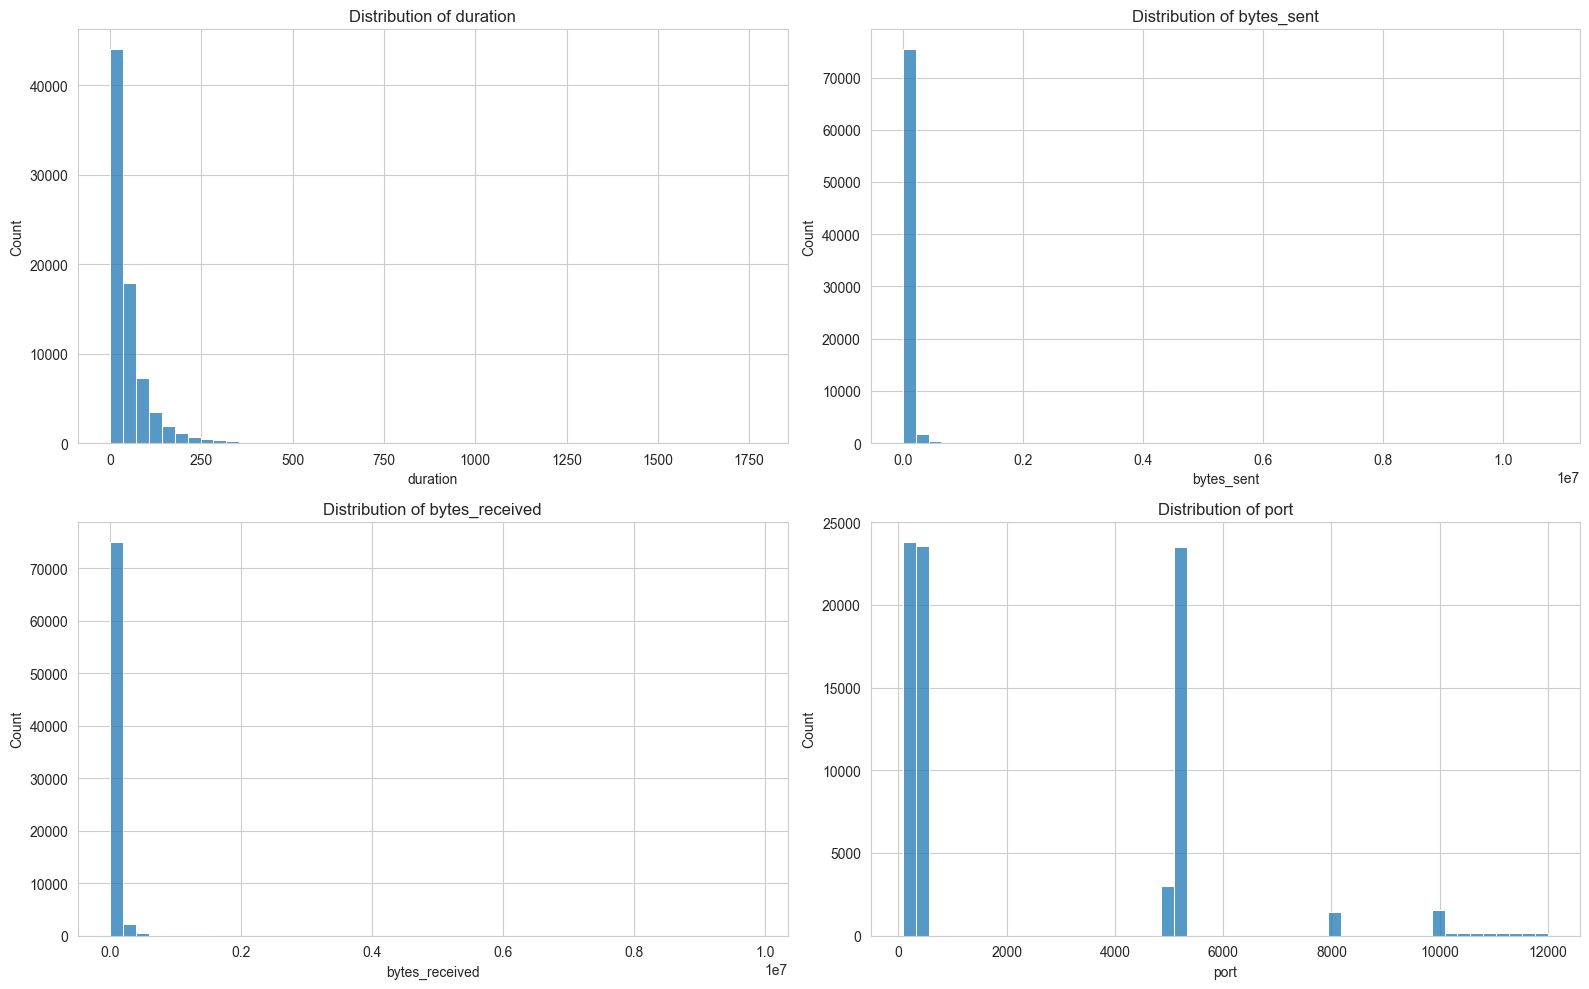


--- 2b. Log-Transformed Numerical Distributions ---


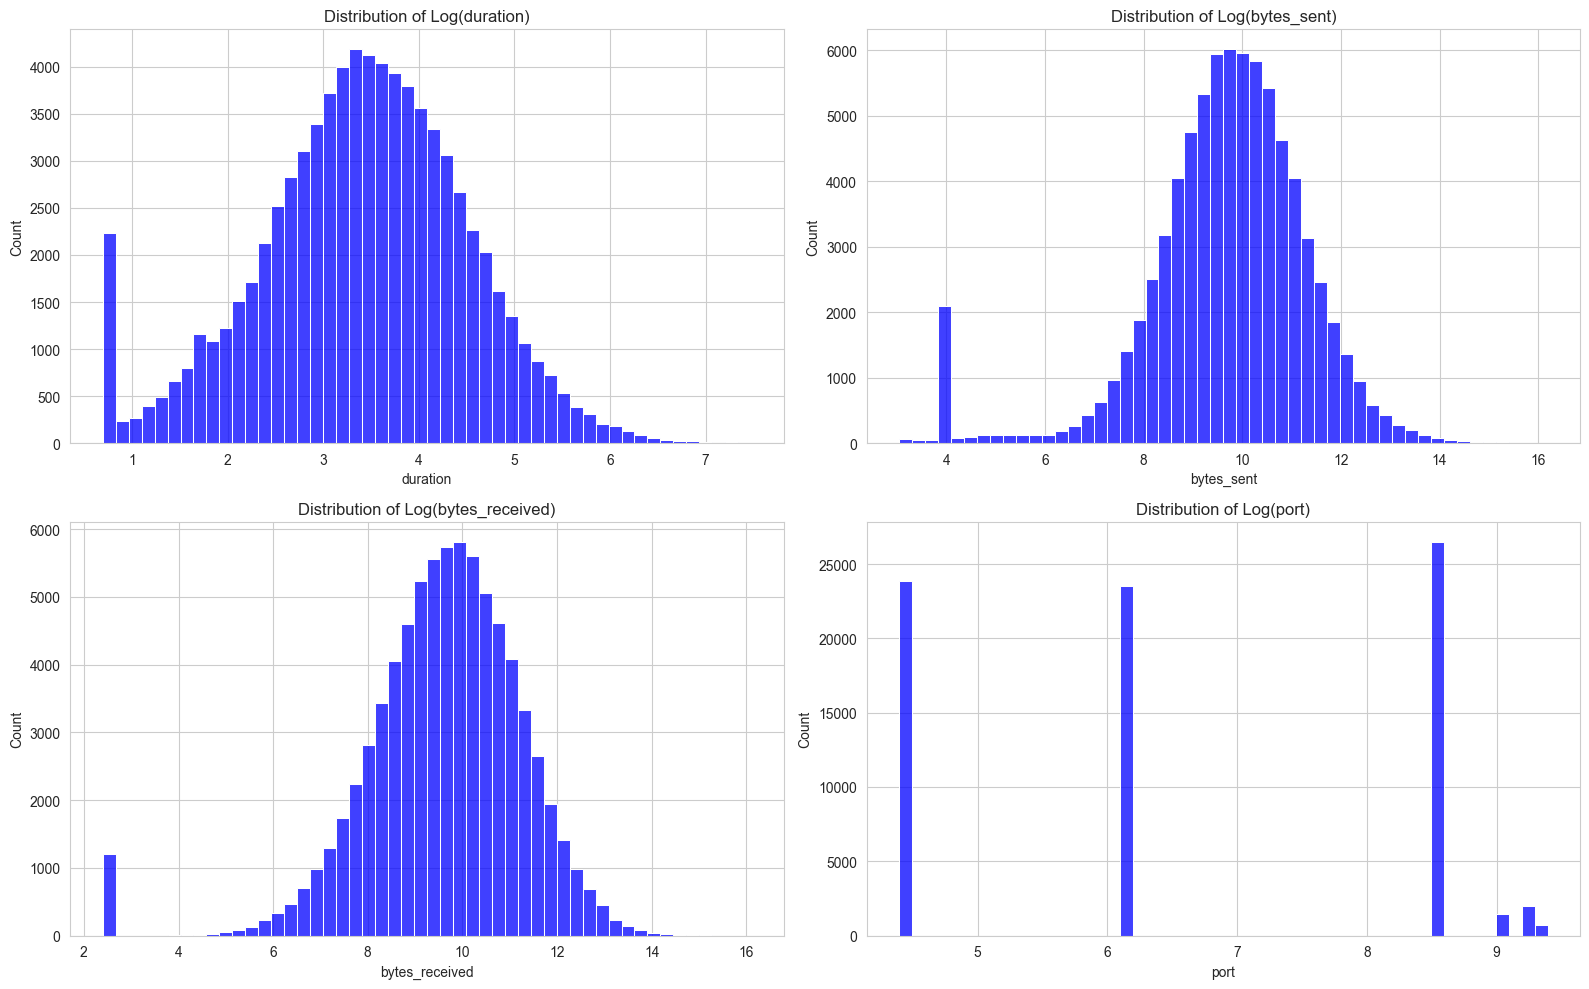

In [3]:
print("--- 2. Numerical Feature Distributions ---")

numerical_features = ['duration', 'bytes_sent', 'bytes_received', 'port']

# Create histograms for each
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten() # Flatten 2x2 array to 1D

for i, feature in enumerate(numerical_features):
    sns.histplot(df_v3_eda[feature], ax=axes[i], bins=50)
    axes[i].set_title(f'Distribution of {feature}')
    
plt.tight_layout()
plt.show()

# --- Log-Transformed Distributions ---
# The plots above are likely skewed. Let's try a log transform.
print("\n--- 2b. Log-Transformed Numerical Distributions ---")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    # Use np.log1p (log(x+1)) to handle zero values
    log_transformed = np.log1p(df_v3_eda[feature])
    sns.histplot(log_transformed, ax=axes[i], bins=50, color='blue')
    axes[i].set_title(f'Distribution of Log({feature})')

plt.tight_layout()
plt.show()

--- 3. Numerical Features vs. Target (Box Plots) ---


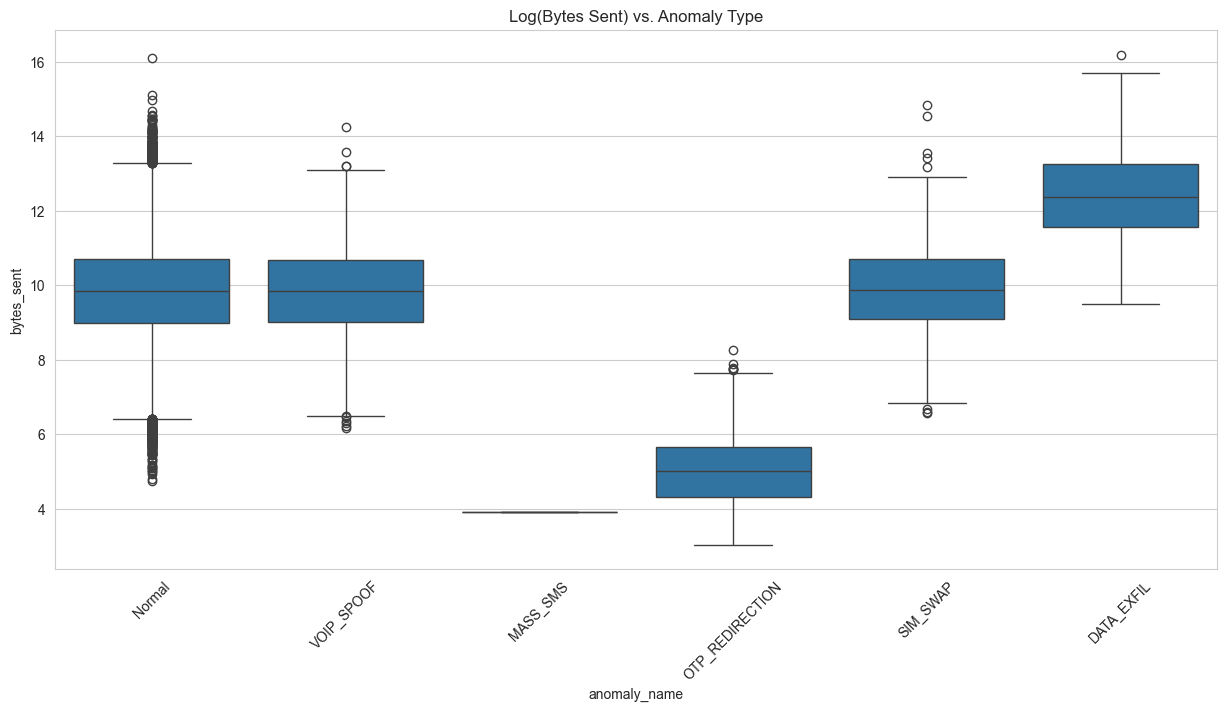

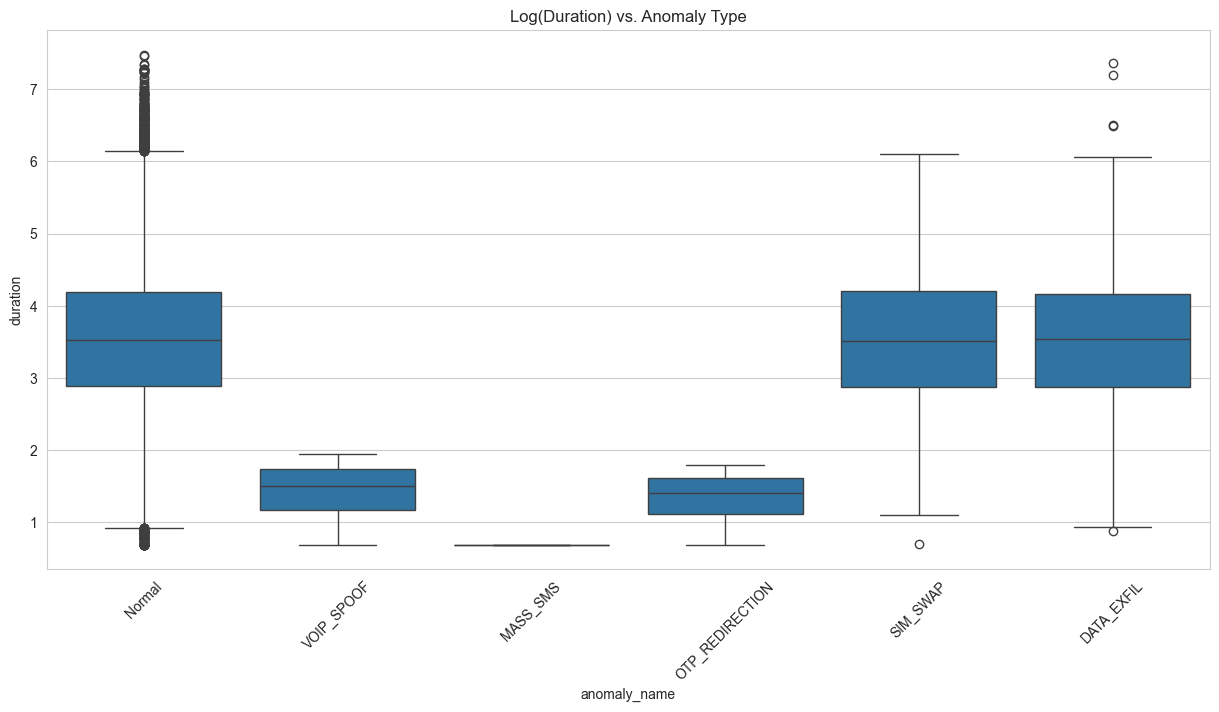

In [4]:
print("--- 3. Numerical Features vs. Target (Box Plots) ---")

# --- Bytes Sent ---
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=df_v3_eda,
    x='anomaly_name',
    y=np.log1p(df_v3_eda['bytes_sent']) # Use log for better visualization
)
plt.title("Log(Bytes Sent) vs. Anomaly Type")
plt.xticks(rotation=45)
plt.show()

# --- Duration ---
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=df_v3_eda,
    x='anomaly_name',
    y=np.log1p(df_v3_eda['duration']) # Use log for better visualization
)
plt.title("Log(Duration) vs. Anomaly Type")
plt.xticks(rotation=45)
plt.show()

--- 4. Categorical Feature Analysis ---
VPN Usage % by Anomaly Type
                   VPN_Off      VPN_On
anomaly_name                          
DATA_EXFIL        0.000000  100.000000
MASS_SMS         98.321816    1.678184
Normal           96.179009    3.820991
OTP_REDIRECTION  95.881826    4.118174
SIM_SWAP         96.834532    3.165468
VOIP_SPOOF       96.736597    3.263403


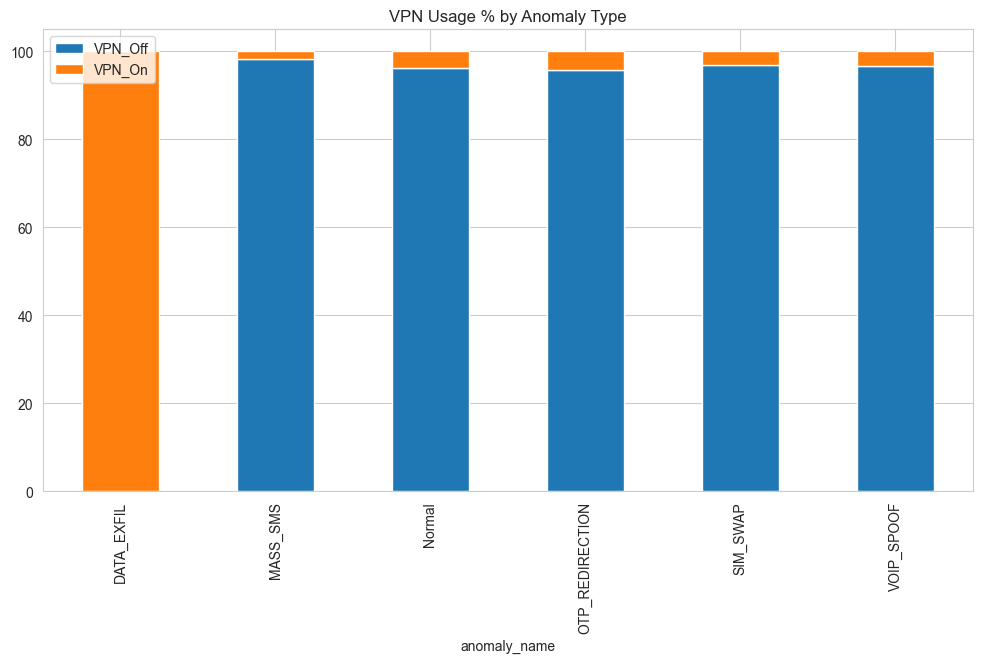


Protocol Distribution by Anomaly Type


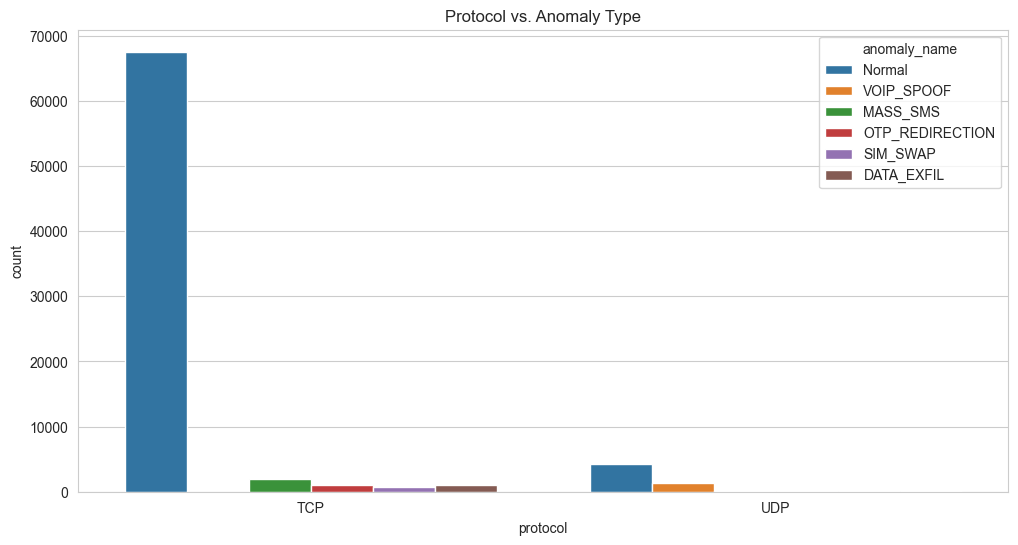


Top 20 Most Frequent Source IPs


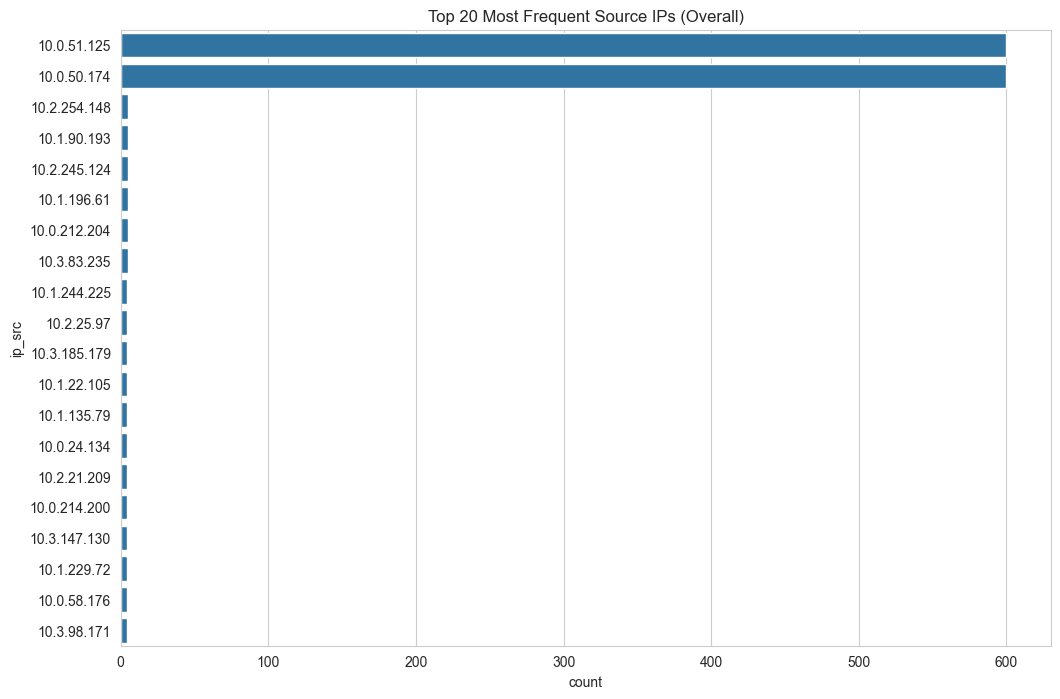

In [5]:
print("--- 4. Categorical Feature Analysis ---")

# --- VPN Usage ---
# (This is the plot we ran before, it's a key part of EDA)
print("VPN Usage % by Anomaly Type")
crosstab_vpn = pd.crosstab(
    df_v3_eda['anomaly_name'],
    df_v3_eda['vpn_usage'],
    normalize='index'
) * 100
crosstab_vpn.columns = ['VPN_Off', 'VPN_On']
print(crosstab_vpn)
crosstab_vpn.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("VPN Usage % by Anomaly Type")
plt.show()

# --- Protocol ---
print("\nProtocol Distribution by Anomaly Type")
plt.figure(figsize=(12, 6))
sns.countplot(data=df_v3_eda, x='protocol', hue='anomaly_name')
plt.title("Protocol vs. Anomaly Type")
plt.show()

# --- Top 20 Source IPs (High-Cardinality) ---
print("\nTop 20 Most Frequent Source IPs")
top_20_ips = df_v3_eda['ip_src'].value_counts().head(20).index
plt.figure(figsize=(12, 8))
sns.countplot(data=df_v3_eda[df_v3_eda['ip_src'].isin(top_20_ips)], y='ip_src', order=top_20_ips)
plt.title("Top 20 Most Frequent Source IPs (Overall)")
plt.show()

--- 5. Relational & Geo-Analysis ---


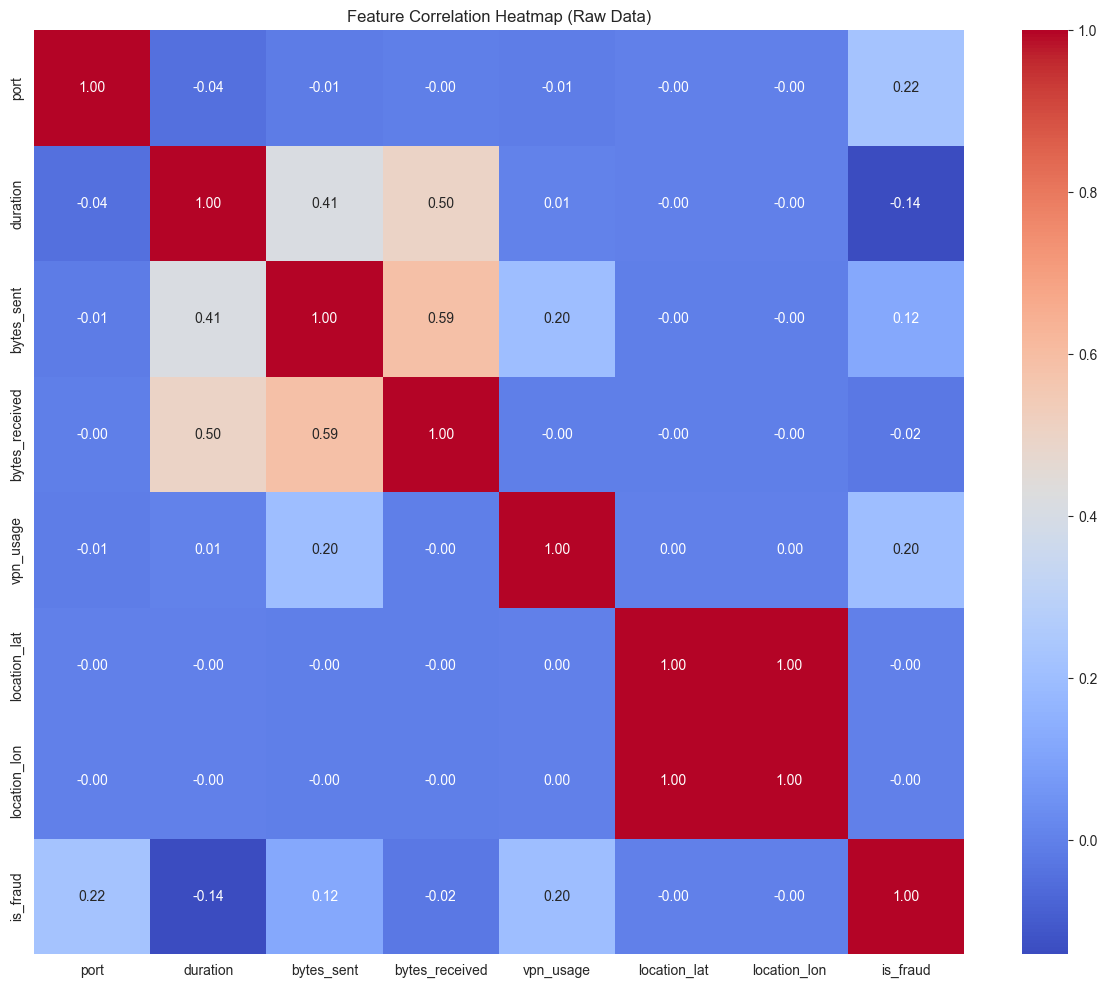


Geographic Distribution of Anomalies


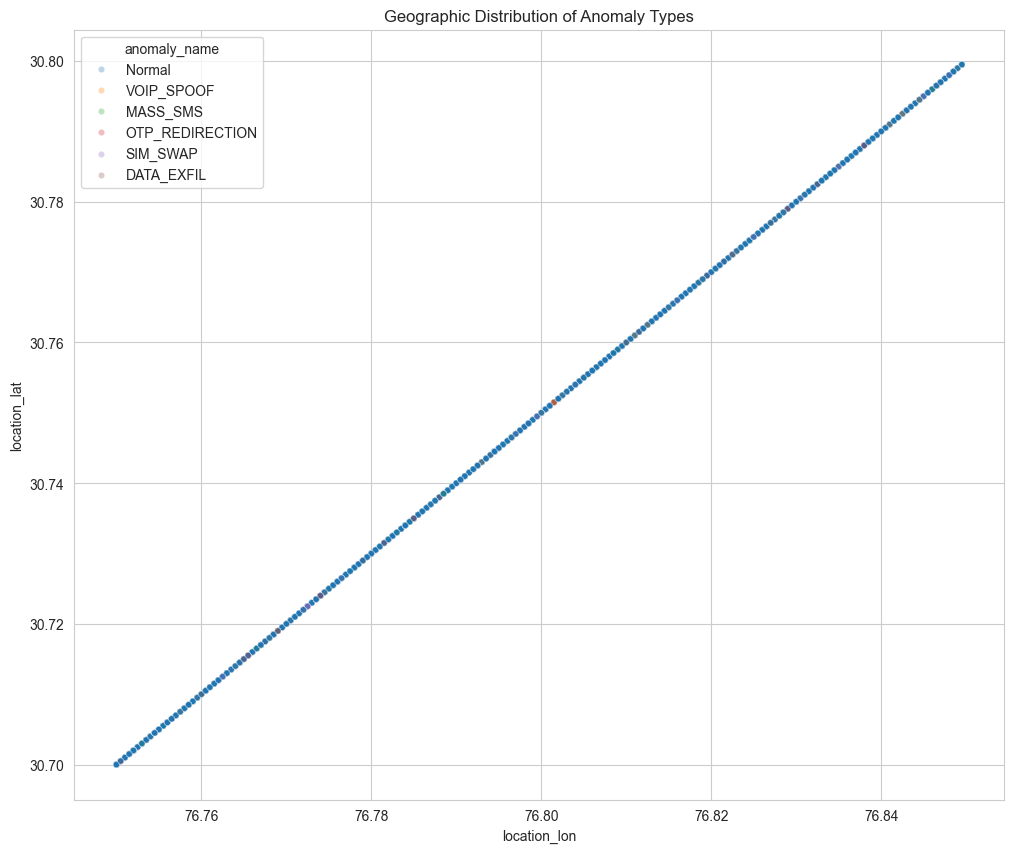

In [6]:
print("--- 5. Relational & Geo-Analysis ---")

# --- Correlation Heatmap ---
# We select only the numerical/boolean columns from the raw data
numeric_cols_for_corr = [
    'port', 'duration', 'bytes_sent', 'bytes_received', 'vpn_usage',
    'location_lat', 'location_lon', 'is_fraud'
]
corr_matrix = df_v3_eda[numeric_cols_for_corr].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Heatmap (Raw Data)")
plt.show()

# --- Geo Plot ---
# (We ran this before, but it belongs in the EDA phase)
print("\nGeographic Distribution of Anomalies")
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_v3_eda, 
    x='location_lon', 
    y='location_lat', 
    hue='anomaly_name', 
    alpha=0.3, 
    s=20
)
plt.title("Geographic Distribution of Anomaly Types")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print("--- Starting 'v3' Model Pipeline ---")

# --- 1. Load Data & Define Constants ---
DATA_FILE = '../data/ipdr_synthetic_fixed.csv' # Use your file path
TARGET_COLUMN = 'anomaly_type'
# Add the new columns we need to drop
DROP_COLUMNS = ['event_id', 'user_id', 'imsi', 'imei', 'runbook_id', 'is_fraud', 'location_lon'] 

try:
    df = pd.read_csv(DATA_FILE)
    print(f"Successfully loaded {len(df)} rows.")
except FileNotFoundError:
    print(f"Error: Data file not found at {DATA_FILE}")

# --- 2. Basic Cleaning (from EDA) ---
df = df.drop(columns=DROP_COLUMNS, errors='ignore')
df[TARGET_COLUMN] = df[TARGET_COLUMN].fillna('Normal')
df['vpn_usage'] = df['vpn_usage'].astype(int)

# --- 3. (NEW) v2 Feature Engineering ---
print("\n--- Starting v2 Feature Engineering ---")

# a) Time-Based Features
try:
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
    df['hour'] = df['timestamp'].dt.hour    
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['is_night'] = ((df['hour'] >= 0) & (df['hour'] <= 6)).astype(int)
    print("  - Created time features: 'hour', 'day_of_week', 'is_night'.")
except Exception as e:
    print(f"  - Timestamp engineering failed: {e}. Skipping.")

# b) Ratio-Based Features
df['bytes_per_duration'] = (df['bytes_sent'] + df['bytes_received']) / (df['duration'] + 1)
print("  - Created ratio feature: 'bytes_per_duration'.")

# c) Rarity-Based Features
print("  - Creating 'rarity' features...")
categorical_features = ['domain', 'ip_src', 'ip_dst', 'protocol', 'cell_id']
feature_encoders = {} # We'll save our LabelEncoders here for the v2 model

for col in categorical_features:
    # First, encode them with LabelEncoder so they are numbers
    # We will still need this for the live pipeline
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    feature_encoders[col] = le # Save the encoder
    
    # Now, create the rarity feature based on the encoded values
    counts = df[col].value_counts(normalize=True)
    df[f'{col}_rarity'] = df[col].map(counts)

print("  - Created 'rarity' features and saved encoders.")

# --- 4. Final Cleanup ---
df = df.drop(columns=['timestamp'], errors='ignore')

print("\n--- v2 Preprocessing Complete ---")
df.head()

--- Starting 'v3' Model Pipeline ---
Successfully loaded 78086 rows.

--- Starting v2 Feature Engineering ---
  - Created time features: 'hour', 'day_of_week', 'is_night'.
  - Created ratio feature: 'bytes_per_duration'.
  - Creating 'rarity' features...
  - Created 'rarity' features and saved encoders.

--- v2 Preprocessing Complete ---


,domain,ip_src,ip_dst,port,protocol,duration,bytes_sent,bytes_received,vpn_usage,cell_id,...,anomaly_type,hour,day_of_week,is_night,bytes_per_duration,domain_rarity,ip_src_rarity,ip_dst_rarity,protocol_rarity,cell_id_rarity
0,1420,2227,45035,80,0,51.060533,137901,37873,0,1428,...,Normal,0,0,1,3376.338879,0.000986,0.000026,0.000026,0.925492,0.000922
1,1446,60554,7482,5228,0,6.946342,2942,2896,0,1791,...,Normal,0,0,1,734.677682,0.001063,0.000026,0.000051,0.925492,0.001498
2,4,46459,37190,5060,0,128.859748,32650,42557,0,1430,...,Normal,0,0,1,579.140197,0.042095,0.000013,0.000013,0.925492,0.001101
3,1720,37428,5601,443,0,49.057434,19906,28281,0,1440,...,Normal,0,0,1,962.634241,0.000256,0.000013,0.000051,0.925492,0.000858
4,1834,26558,14638,80,0,3.613882,2772,3521,0,455,...,Normal,0,0,1,1363.927267,0.001063,0.000026,0.000026,0.925492,0.001037


--- 1. 'is_night' vs. Anomaly Type ---
                   Daytime  Nighttime
anomaly_type                         
DATA_EXFIL       70.205174  29.794826
MASS_SMS         88.153998  11.846002
Normal           72.000278  27.999722
OTP_REDIRECTION  72.963295  27.036705
SIM_SWAP         75.539568  24.460432
VOIP_SPOOF       71.794872  28.205128


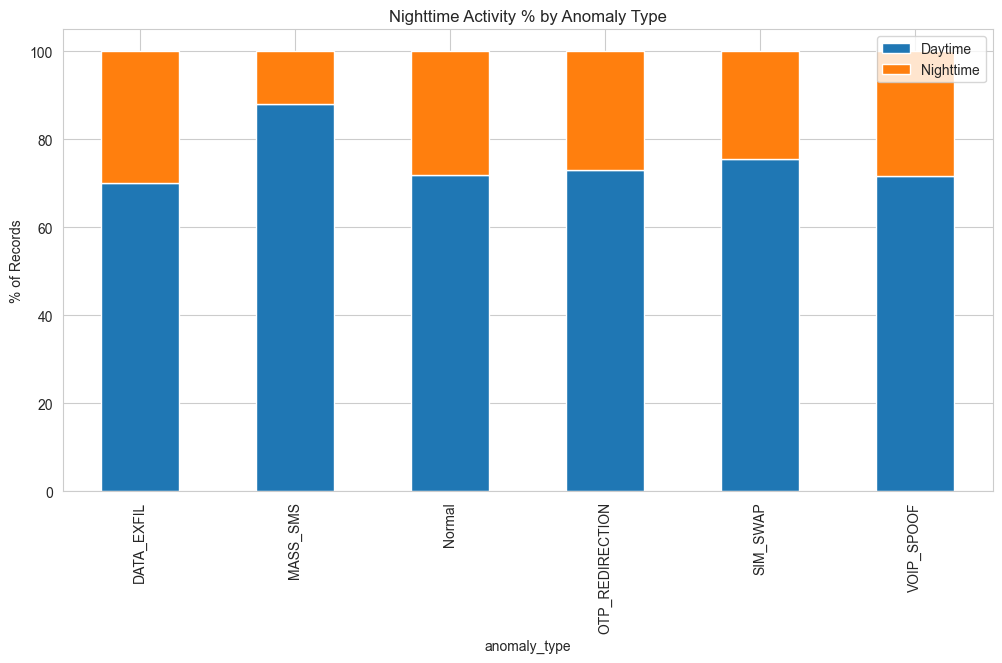

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 1. 'is_night' vs. Anomaly Type ---")

# Create a cross-tabulation (percentage-based)
crosstab_night = pd.crosstab(
    df['anomaly_type'],
    df['is_night'],
    normalize='index' # This gives us %
) * 100
crosstab_night.columns = ['Daytime', 'Nighttime']

print(crosstab_night)

# Plot it
crosstab_night.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Nighttime Activity % by Anomaly Type")
plt.ylabel("% of Records")
plt.show()


--- 2. 'bytes_per_duration' vs. Anomaly Type ---


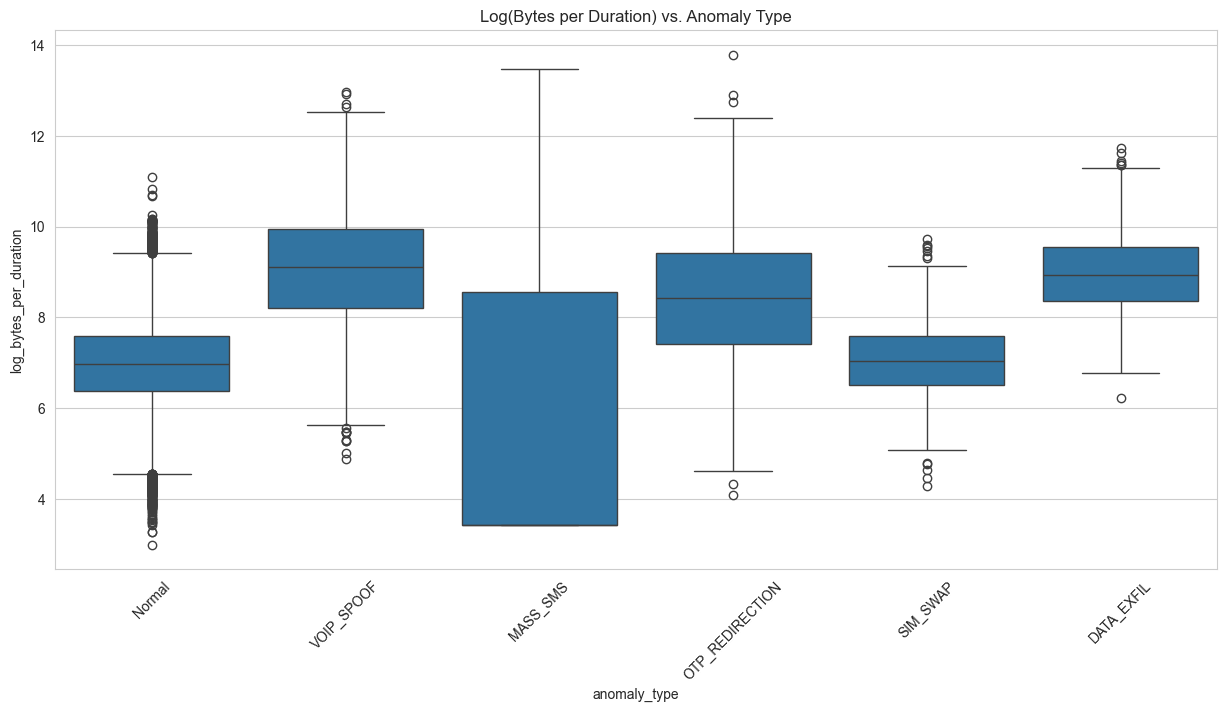

In [11]:
print("\n--- 2. 'bytes_per_duration' vs. Anomaly Type ---")

# We'll use a log scale because this value can be huge
df['log_bytes_per_duration'] = np.log1p(df['bytes_per_duration'])

plt.figure(figsize=(15, 7))
sns.boxplot(data=df, x='anomaly_type', y='log_bytes_per_duration')
plt.title("Log(Bytes per Duration) vs. Anomaly Type")
plt.xticks(rotation=45)
plt.show()


--- 3. 'Rarity' Features vs. Anomaly Type ---


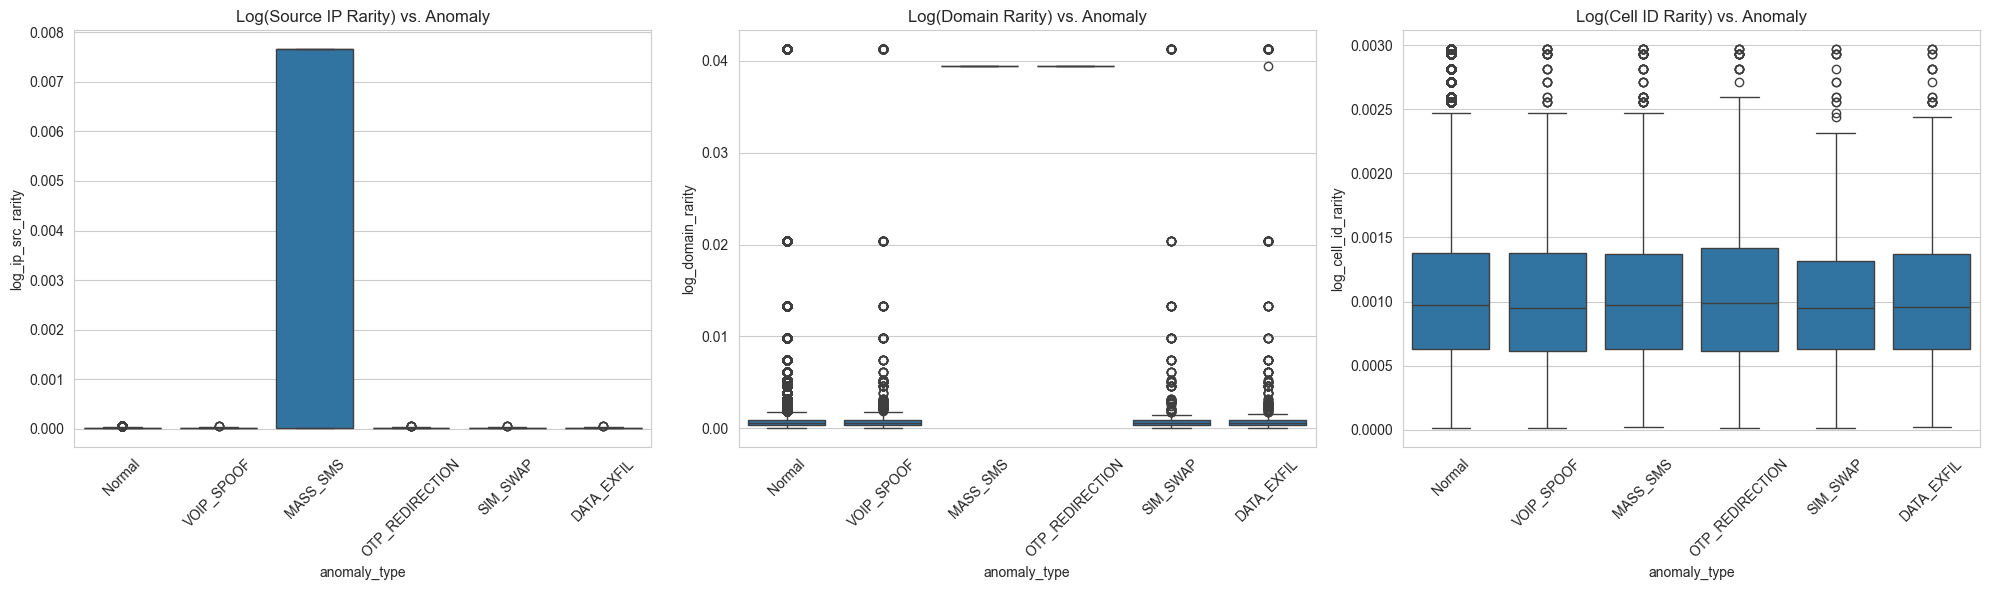

In [12]:
print("\n--- 3. 'Rarity' Features vs. Anomaly Type ---")

# We'll log-transform rarity
df['log_ip_src_rarity'] = np.log1p(df['ip_src_rarity'])
df['log_domain_rarity'] = np.log1p(df['domain_rarity'])
df['log_cell_id_rarity'] = np.log1p(df['cell_id_rarity'])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot IP Rarity
sns.boxplot(data=df, x='anomaly_type', y='log_ip_src_rarity', ax=axes[0])
axes[0].set_title("Log(Source IP Rarity) vs. Anomaly")
axes[0].tick_params(axis='x', rotation=45)

# Plot Domain Rarity
sns.boxplot(data=df, x='anomaly_type', y='log_domain_rarity', ax=axes[1])
axes[1].set_title("Log(Domain Rarity) vs. Anomaly")
axes[1].tick_params(axis='x', rotation=45)

# Plot Cell ID Rarity
sns.boxplot(data=df, x='anomaly_type', y='log_cell_id_rarity', ax=axes[2])
axes[2].set_title("Log(Cell ID Rarity) vs. Anomaly")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

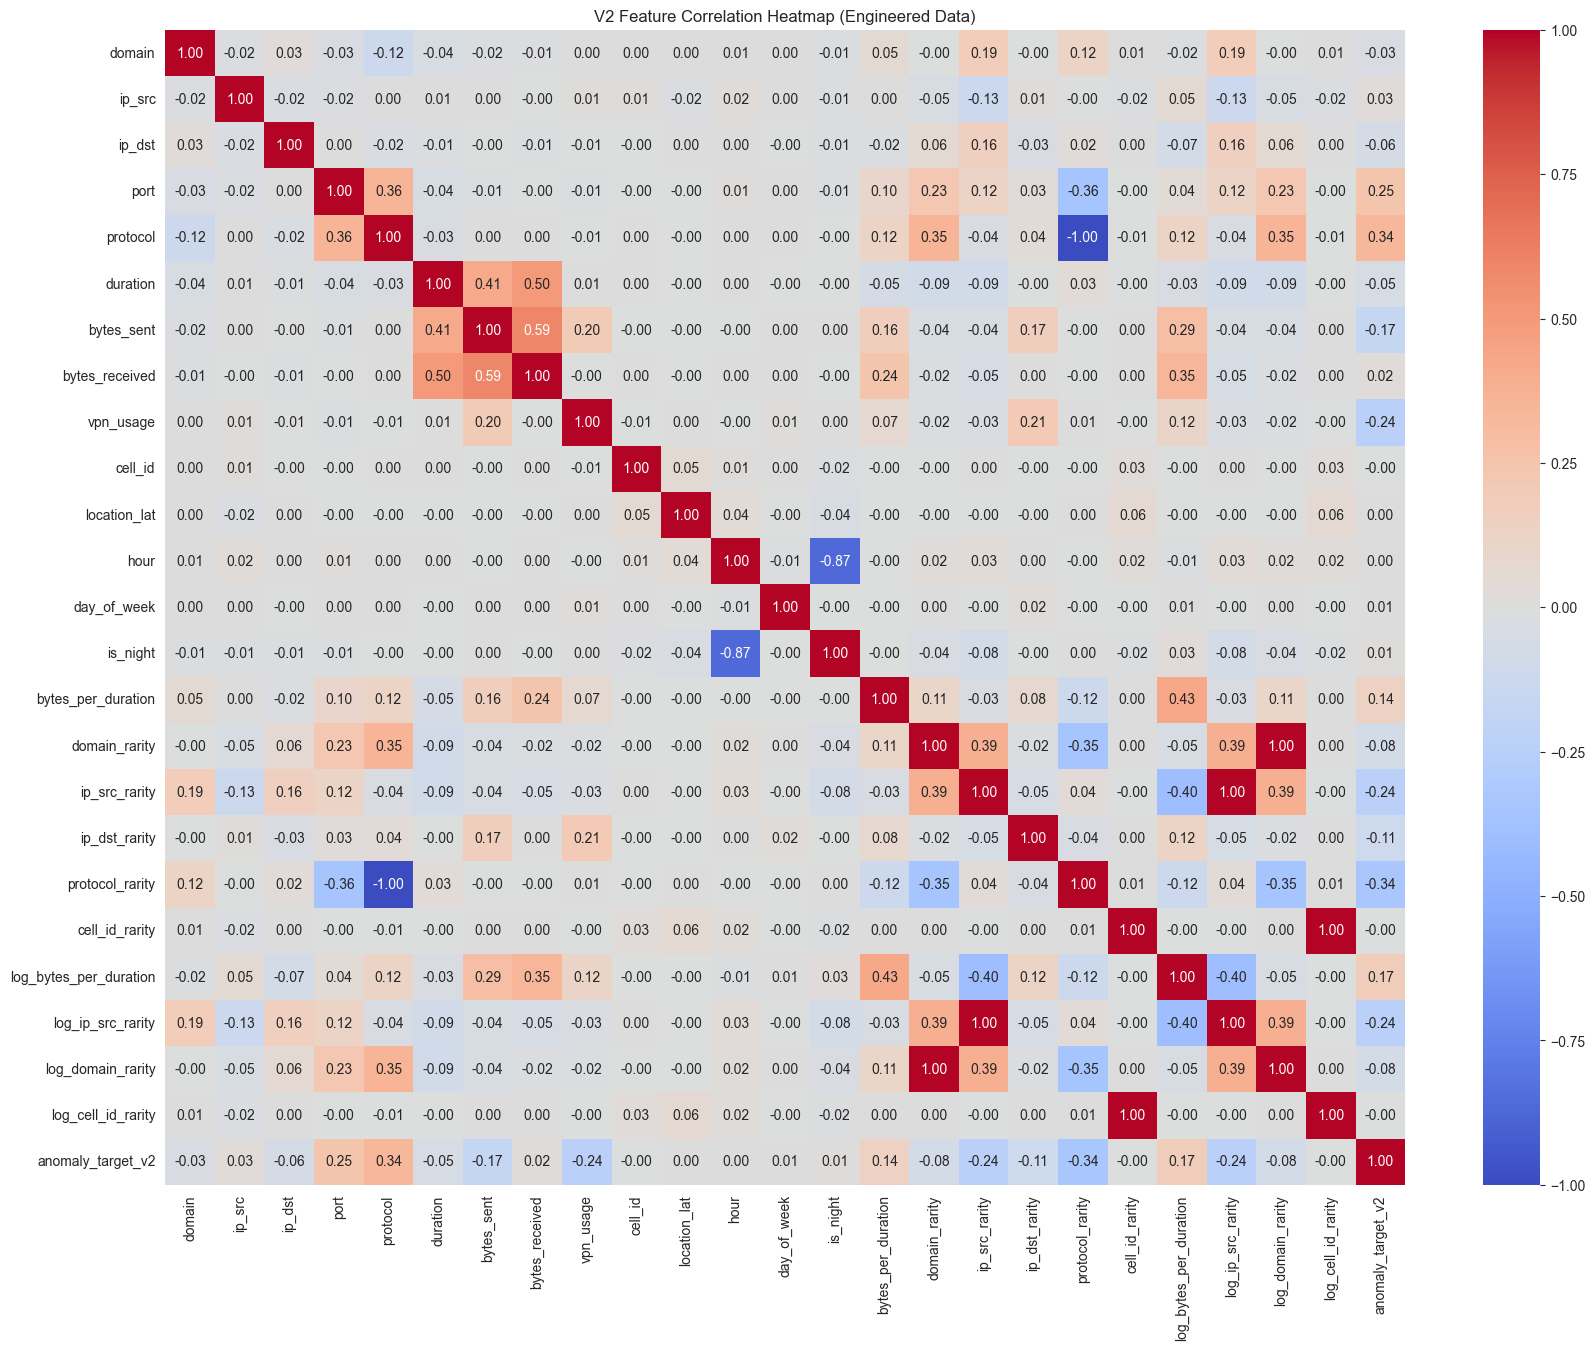

In [13]:
# First, we need to encode our target 'anomaly_name' to a number
target_encoder = LabelEncoder()
df['anomaly_target_v2'] = target_encoder.fit_transform(df['anomaly_type'])

# Select all numeric columns for the heatmap
numeric_v2_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(20, 15))
sns.heatmap(df[numeric_v2_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("V2 Feature Correlation Heatmap (Engineered Data)")
plt.show()

In [14]:
print("--- Final v2 Feature Selection ---")

# From our EDA, log_cell_id_rarity is useless.
# Let's drop it and all the other log-transformed columns we created just for plotting
try:
    df = df.drop(columns=[
        'log_bytes_per_duration', 
        'log_ip_src_rarity', 
        'log_domain_rarity', 
        'log_cell_id_rarity',
        'cell_id_rarity' # The original was also not useful
    ], errors='ignore')
    
    # We also need to encode our target 'anomaly_type' for training
    target_encoder = LabelEncoder()
    df['anomaly_target_v2'] = target_encoder.fit_transform(df['anomaly_type'])
    df = df.drop(columns=['anomaly_type']) # Drop the string version
    
    print("Dropped plotting-only and useless features.")
    print("Final DataFrame head:")
    print(df.head())
    
except Exception as e:
    print(f"Error during column drop: {e}")

--- Final v2 Feature Selection ---
Dropped plotting-only and useless features.
Final DataFrame head:
   domain  ip_src  ip_dst  port  protocol    duration  bytes_sent  \
0    1420    2227   45035    80         0   51.060533      137901   
1    1446   60554    7482  5228         0    6.946342        2942   
2       4   46459   37190  5060         0  128.859748       32650   
3    1720   37428    5601   443         0   49.057434       19906   
4    1834   26558   14638    80         0    3.613882        2772   

   bytes_received  vpn_usage  cell_id  location_lat  hour  day_of_week  \
0           37873          0     1428       30.7115     0            0   
1            2896          0     1791       30.7855     0            0   
2           42557          0     1430       30.7125     0            0   
3           28281          0     1440       30.7180     0            0   
4            3521          0      455       30.7715     0            0   

   is_night  bytes_per_duration  domain

Loading data from ../data/ipdr_synthetic_fixed.csv...
Data loaded: 78086 rows.
Engineering stateful features (v3)...
Engineering stateless features (v2)...

--- Starting Training Pipeline ---
Features used for training: 20
Columns: ['domain', 'ip_src', 'ip_dst', 'port', 'protocol', 'duration', 'bytes_sent', 'bytes_received', 'vpn_usage', 'cell_id', 'location_lat', 'imei_changed', 'hour', 'day_of_week', 'is_night', 'bytes_per_duration', 'domain_rarity', 'ip_src_rarity', 'ip_dst_rarity', 'protocol_rarity']
Applying SMOTE to handle imbalance...
Training XGBoost...


C:\Users\bansa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [17:03:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Evaluation Results ---
                 precision    recall  f1-score   support

     DATA_EXFIL       0.97      0.96      0.97       224
       MASS_SMS       1.00      1.00      1.00       405
         Normal       1.00      1.00      1.00     14369
OTP_REDIRECTION       1.00      1.00      1.00       223
       SIM_SWAP       0.86      0.55      0.67       139
     VOIP_SPOOF       1.00      1.00      1.00       258

       accuracy                           0.99     15618
      macro avg       0.97      0.92      0.94     15618
   weighted avg       0.99      0.99      0.99     15618



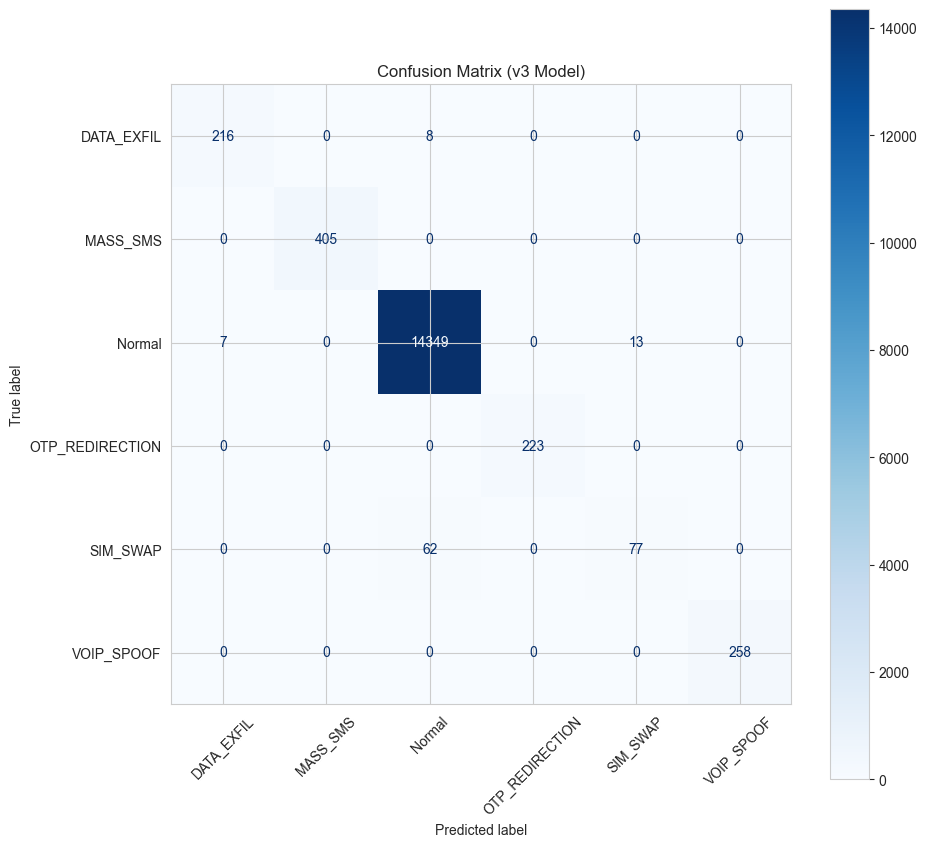


--- Saving 5 Artifacts (v3_*) ---
Save complete.


In [ ]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# --- 1. CONFIGURATION & CONSTANTS ---
DATA_FILE = '../data/ipdr_synthetic_fixed.csv'
ARTIFACT_PREFIX = 'v3_'
TARGET_COLUMN = 'anomaly_type'

# Columns to drop IMMEDIATELY (Ids we don't need for stateful logic)
INITIAL_DROP_COLS = [
    'event_id', 'user_id', 'runbook_id', 'is_fraud', 'location_lon'
]

# Columns to drop AFTER feature engineering (before training)
FINAL_DROP_COLS = [
    'imsi', 'imei', 'timestamp', 'cell_id_rarity'
]

CATEGORICAL_COLS = ['domain', 'ip_src', 'ip_dst', 'protocol', 'cell_id']

# --- 2. DATA LOADING & CLEANING ---
def load_and_clean_data(filepath):
    print(f"Loading data from {filepath}...")
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        raise FileNotFoundError(f"Critical Error: Data file not found at {filepath}")
    
    # Only drop the IDs we truly don't need yet. Keep IMSI/IMEI.
    df = df.drop(columns=INITIAL_DROP_COLS, errors='ignore')
    
    # Handle Target
    df[TARGET_COLUMN] = df[TARGET_COLUMN].fillna('Normal')
    
    # Handle Booleans
    if 'vpn_usage' in df.columns:
        df['vpn_usage'] = df['vpn_usage'].astype(int)
        
    print(f"Data loaded: {len(df)} rows.")
    return df

# --- 3. FEATURE ENGINEERING (STATEFUL - v3) ---
def engineer_stateful_features(df):
    print("Engineering stateful features (v3)...")
    
    # Ensure time sort order for sequential analysis
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
    
    # We NEED 'imsi' here, so it's good we didn't drop it yet
    df = df.sort_values(by=['imsi', 'timestamp'])
    
    # Create 'imei_changed'
    df['previous_imei'] = df.groupby('imsi')['imei'].shift(1)
    df['imei_changed'] = (df['imei'] != df['previous_imei']).astype(int).fillna(0)
    
    # Clean up helper column
    df = df.drop(columns=['previous_imei'])
    return df

# --- 4. FEATURE ENGINEERING (STATELESS - v2) ---
def engineer_stateless_features(df):
    print("Engineering stateless features (v2)...")
    
    # A) Time-based
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['is_night'] = ((df['hour'] >= 0) & (df['hour'] <= 6)).astype(int)
    
    # B) Ratio-based
    df['bytes_per_duration'] = (df['bytes_sent'] + df['bytes_received']) / (df['duration'] + 1)
    
    # C) Rarity & Encoding
    feature_encoders = {}
    rarity_maps = {}
    
    for col in CATEGORICAL_COLS:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        feature_encoders[col] = le
        
        counts = df[col].value_counts(normalize=True)
        df[f'{col}_rarity'] = df[col].map(counts)
        rarity_maps[col] = counts.to_dict()
        
    # NOW we drop the columns we don't need for training (imsi, imei, timestamp)
    df = df.drop(columns=FINAL_DROP_COLS, errors='ignore')
    
    return df, feature_encoders, rarity_maps

# --- 5. TRAINING ---
def train_model(df):
    print("\n--- Starting Training Pipeline ---")
    
    # Encode Target
    target_encoder = LabelEncoder()
    df[TARGET_COLUMN] = target_encoder.fit_transform(df[TARGET_COLUMN])
    
    # Split X and y
    X = df.drop(columns=[TARGET_COLUMN])
    y = df[TARGET_COLUMN]
    model_columns = X.columns.tolist()
    
    print(f"Features used for training: {len(model_columns)}")
    print(f"Columns: {model_columns}")
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # SMOTE (Oversampling)
    print("Applying SMOTE to handle imbalance...")
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    
    # Train XGBoost
    print("Training XGBoost...")
    model = xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=len(y.unique()),
        eval_metric='mlogloss',
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_res, y_train_res)
    
    return model, target_encoder, X_test, y_test, model_columns

# --- 6. EVALUATION ---
def evaluate_model(model, X_test, y_test, target_encoder):
    print("\n--- Evaluation Results ---")
    y_pred = model.predict(X_test)
    
    y_test_labels = target_encoder.inverse_transform(y_test)
    y_pred_labels = target_encoder.inverse_transform(y_pred)
    
    print(classification_report(y_test_labels, y_pred_labels))
    
    cm = confusion_matrix(y_test_labels, y_pred_labels, labels=target_encoder.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap='Blues', ax=ax)
    plt.xticks(rotation=45)
    plt.title("Confusion Matrix (v3 Model)")
    plt.show()
    

# --- 7. SAVE ARTIFACTS ---
def save_artifacts(model, target_enc, feature_encs, model_cols, rarity_maps):
    print(f"\n--- Saving 5 Artifacts ({ARTIFACT_PREFIX}*) ---")
    
    joblib.dump(model, f'{ARTIFACT_PREFIX}xgboost_model.joblib')
    joblib.dump(target_enc, f'{ARTIFACT_PREFIX}target_encoder.joblib')
    joblib.dump(feature_encs, f'{ARTIFACT_PREFIX}feature_encoders.joblib')
    joblib.dump(model_cols, f'{ARTIFACT_PREFIX}model_columns.joblib')
    joblib.dump(rarity_maps, f'{ARTIFACT_PREFIX}rarity_maps.joblib')
    
    print("Save complete.")

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    # 1. Load (Keeps IMSI/IMEI)
    df_raw = load_and_clean_data(DATA_FILE)
    
    # 2. Stateful Engineering (Uses IMSI/IMEI)
    df_stateful = engineer_stateful_features(df_raw)
    
    # 3. Stateless Engineering & Cleanup (Drops IMSI/IMEI at the end)
    df_final, feat_encoders, rarity_maps = engineer_stateless_features(df_stateful)
    
    # 4. Train
    model_v3, target_enc, X_test, y_test, model_cols = train_model(df_final)
    
    # 5. Evaluate
    evaluate_model(model_v3, X_test, y_test, target_enc)
    
    # 6. Save
    save_artifacts(model_v3, target_enc, feat_encoders, model_cols, rarity_maps)

--- Analyzing 'v3' Features ---


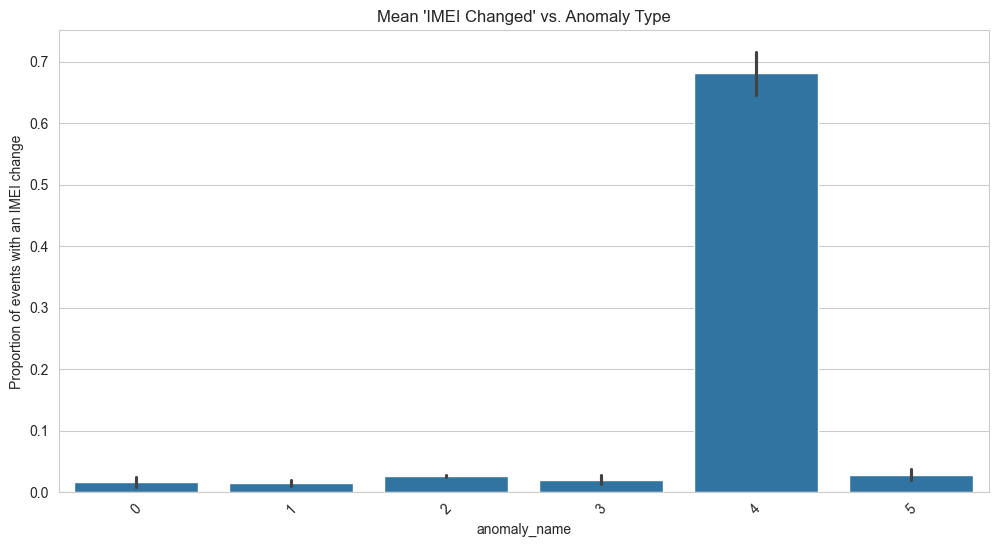

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Analyzing 'v3' Features ---")

# We need our 'anomaly_name' column for plotting
df_final['anomaly_name'] = df_final['anomaly_type'].fillna('Normal')

# --- Plot 'imei_changed' vs. Anomaly Type ---
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_final,
    x='anomaly_name',
    y='imei_changed'
)
plt.title("Mean 'IMEI Changed' vs. Anomaly Type")
plt.ylabel("Proportion of events with an IMEI change")
plt.xticks(rotation=45)
plt.show()

In [19]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("--- Generating SHAP Values for 'v3' Model ---")

# 1. Create the TreeExplainer for our 'model_v3'
explainer_v3 = shap.TreeExplainer(model_v3)

# 2. Calculate SHAP values for our 'v3' test data (X_test)
# (This uses the X_test from the previous cell)
shap_values_v3 = explainer_v3.shap_values(X_test)

print("--- 'v3' SHAP values generated. ---")

C:\Users\bansa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Generating SHAP Values for 'v3' Model ---
--- 'v3' SHAP values generated. ---


--- Creating 'v3' SHAP Summary Plot (All Classes) ---


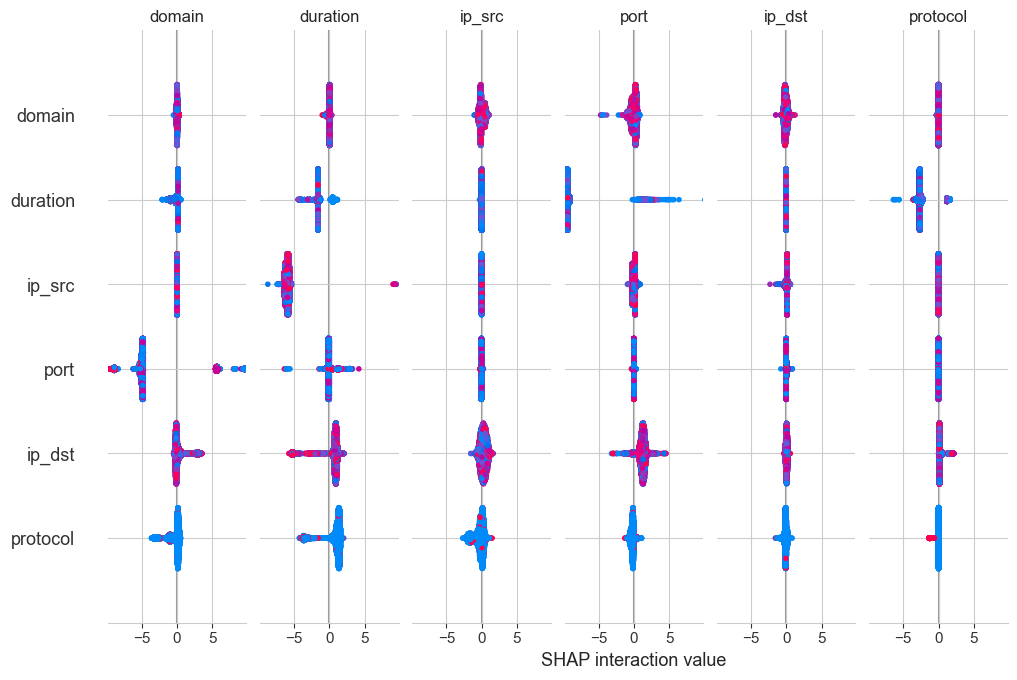

In [21]:
print("--- Creating 'v3' SHAP Summary Plot (All Classes) ---")

# Get the human-readable class names from our 'target_encoder_v3'
class_names_v3 = target_enc.classes_

# Create the summary plot
# This will generate 6 separate beeswarm plots
shap.summary_plot(
    shap_values_v3, 
    X_test, 
    class_names=class_names_v3
)

--- 'v3' Local Explanation: Autopsy of a *Correctly* Classified SIM_SWAP ---
Analyzing correctly classified record at X_test index: 21

--- Force Plot: Why was this predicted 'SIM_SWAP'? ---


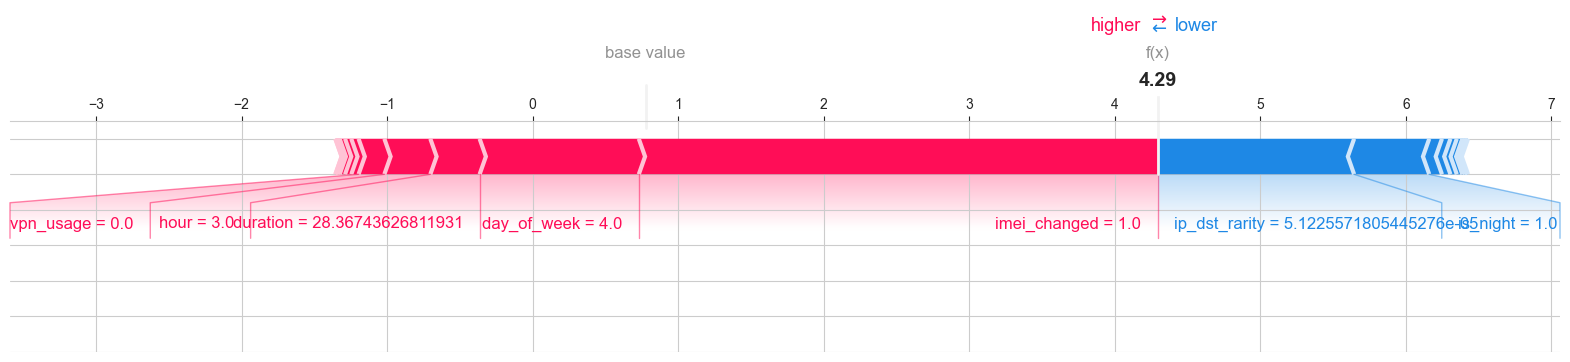

In [23]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("--- 'v3' Local Explanation: Autopsy of a *Correctly* Classified SIM_SWAP ---")

# 1. Find a correctly classified SIM_SWAP
true_sim_swap_index = target_enc.transform(['SIM_SWAP'])[0]
y_pred = model_v3.predict(X_test)
correctly_classified_indices = np.where(
    (y_test == true_sim_swap_index) & (y_pred == true_sim_swap_index)
)[0]

if len(correctly_classified_indices) > 0:
    # 2. Get the first correct record
    record_index = correctly_classified_indices[0]
    record_to_explain = X_test.iloc[[record_index]] # Get the DataFrame row
    
    print(f"Analyzing correctly classified record at X_test index: {record_index}")

    # 3. Calculate SHAP values for just this one record
    shap_values_instance = explainer_v3.shap_values(record_to_explain)
    
    # 4. Get the base value (average prediction)
    base_value = explainer_v3.expected_value
    
    # --- THIS IS THE PROOF ---

    # 5. Create the force plot for 'SIM_SWAP'
    print(f"\n--- Force Plot: Why was this predicted 'SIM_SWAP'? ---")
    
    # Slice [sample 0, all features, for 'SIM_SWAP' class]
    shap_values_for_sim_swap = shap_values_instance[0, :, true_sim_swap_index]
    
    shap.force_plot(
        base_value[true_sim_swap_index],
        shap_values_for_sim_swap,
        record_to_explain.iloc[0], # Pass the 1D Series of features
        matplotlib=True
    )
    plt.show()

else:
    print("Could not find any correctly classified SIM_SWAP records to analyze.")

In [26]:
print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
Index: 78086 entries, 9749 to 67825
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   domain              78086 non-null  int64  
 1   ip_src              78086 non-null  int64  
 2   ip_dst              78086 non-null  int64  
 3   port                78086 non-null  int64  
 4   protocol            78086 non-null  int64  
 5   duration            78086 non-null  float64
 6   bytes_sent          78086 non-null  int64  
 7   bytes_received      78086 non-null  int64  
 8   vpn_usage           78086 non-null  int64  
 9   cell_id             78086 non-null  int64  
 10  location_lat        78086 non-null  float64
 11  anomaly_type        78086 non-null  int64  
 12  imei_changed        78086 non-null  int64  
 13  hour                78086 non-null  int32  
 14  day_of_week         78086 non-null  int32  
 15  is_night            78086 non-null  int64  
 16  bytes_

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

print("--- Phase 2: VAE Data Preparation ---")

# 1. Define the Numerical Columns we want the VAE to learn
vae_features = [
    'duration', 
    'bytes_sent', 
    'bytes_received', 
    'bytes_per_duration',
    'hour',             # Time is useful for patterns
    'is_night'          # Boolean is fine (0 or 1)
]

# 2. Separate Data for VAE Training
# The VAE must only see "Normal" data during training.
# *** FIX: Use 'anomaly_type' instead of 'anomaly_target_v2' ***

# We assume target_enc is the encoder you got from the previous training step
# If "target_enc" is not defined, use the variable name you saved it as (e.g., target_encoder)
normal_label = target_enc.transform(['Normal'])[0]

X_normal = df_final[df_final['anomaly_type'] == normal_label]
X_normal = X_normal[vae_features]

# 3. Scale the Data (Crucial for Neural Networks)
scaler = MinMaxScaler()
# Fit ONLY on normal data
X_normal_scaled = scaler.fit_transform(X_normal)

# Prepare the full dataset (Normal + Fraud) for generating the feature later
X_all_scaled = scaler.transform(df_final[vae_features])

print(f"VAE Training Data Shape (Normal Only): {X_normal_scaled.shape}")
print(f"Full Dataset Shape (For Feature Generation): {X_all_scaled.shape}")

--- Phase 2: VAE Data Preparation ---
VAE Training Data Shape (Normal Only): (71840, 6)
Full Dataset Shape (For Feature Generation): (78086, 6)


In [28]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

print("\n--- Building the Autoencoder (VAE Layer) ---")

input_dim = X_normal_scaled.shape[1] # Number of features (e.g., 6)

# 1. The Encoder (Compresses the data)
input_layer = Input(shape=(input_dim,))
encoder = Dense(8, activation="relu")(input_layer)
encoder = Dense(4, activation="relu")(encoder) # Bottleneck layer (compressed state)

# 2. The Decoder (Tries to reconstruct the data)
decoder = Dense(8, activation="relu")(encoder)
decoder = Dense(input_dim, activation="sigmoid")(decoder) # Sigmoid outputs 0-1 (matching our scaler)

# 3. Compile the Model
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 4. Train on Normal Data Only
# We want it to be really good at recreating Normal data
print("Training Autoencoder...")
history = autoencoder.fit(
    X_normal_scaled, X_normal_scaled,
    epochs=20,
    batch_size=32,
    shuffle=True,
    validation_split=0.1,
    verbose=0 # Set to 1 to see training progress
)
print("VAE/Autoencoder Training Complete.")

C:\Users\bansa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\bansa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\bansa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Pyt


--- Building the Autoencoder (VAE Layer) ---
Training Autoencoder...
VAE/Autoencoder Training Complete.



--- Generating 'vae_anomaly_score' ---
2441/2441 ━━━━━━━━━━━━━━━━━━━━ 2s 794us/step
Feature created.
Anomaly Score Stats:
 count    7.808600e+04
mean     1.902557e-03
std      1.418426e-01
min      7.165336e-08
25%      7.952843e-06
50%      1.644137e-05
75%      3.152769e-05
max      3.275193e+01
Name: vae_anomaly_score, dtype: float64

--- Visualizing Anomaly Scores ---


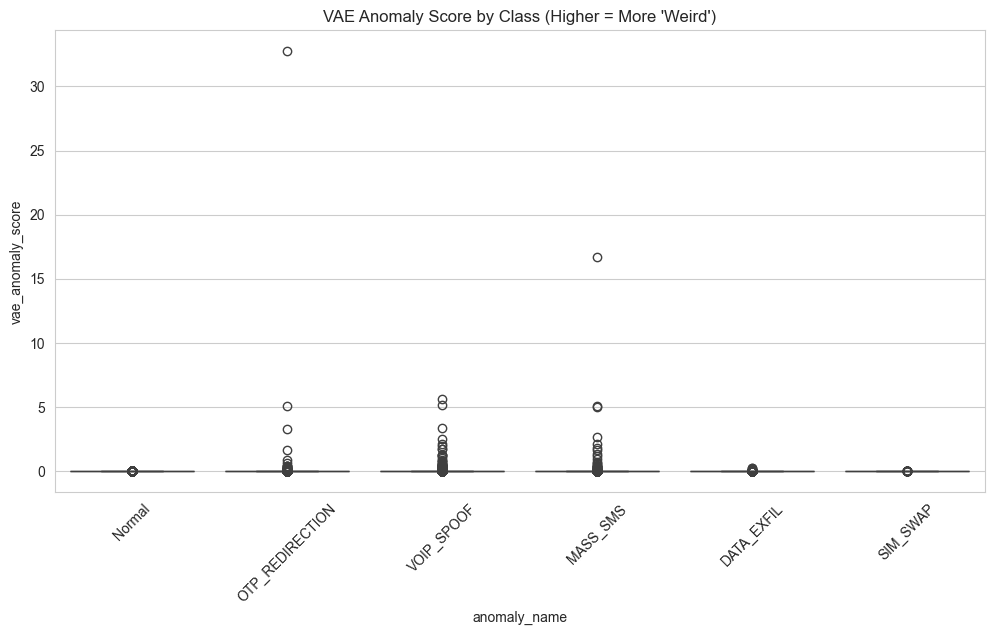

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Generating 'vae_anomaly_score' ---")

# 1. Get reconstructions for the ENTIRE dataset
# (Make sure 'autoencoder' and 'X_all_scaled' are defined from the previous training step)
reconstructions = autoencoder.predict(X_all_scaled)

# 2. Calculate MSE (Mean Squared Error) for each row
# Logic: mean((Input - Output)^2)
mse = np.mean(np.power(X_all_scaled - reconstructions, 2), axis=1)

# 3. Add this as a NEW FEATURE to our DataFrame
df_v4 = df_final.copy()
df_v4['vae_anomaly_score'] = mse

print("Feature created.")
print("Anomaly Score Stats:\n", df_v4['vae_anomaly_score'].describe())

# 4. Visualize separation
print("\n--- Visualizing Anomaly Scores ---")
plt.figure(figsize=(12, 6))

# Helper: Create a temporary column with readable names for the plot
# We use the 'target_encoder' (or 'target_enc') from the v3 pipeline
if 'target_enc' in globals():
    encoder = target_enc
elif 'target_encoder' in globals():
    encoder = target_encoder
else:
    encoder = None

if encoder:
    df_v4['anomaly_name'] = encoder.inverse_transform(df_v4['anomaly_type'])
    plot_x = 'anomaly_name'
else:
    # Fallback if encoder is missing
    plot_x = 'anomaly_type'

# Plot
sns.boxplot(data=df_v4, x=plot_x, y='vae_anomaly_score')
plt.title("VAE Anomaly Score by Class (Higher = More 'Weird')")
plt.xticks(rotation=45)
plt.show()


--- Training 'v4' Hybrid Model ---
Training Features: 21
Feature Names: ['domain', 'ip_src', 'ip_dst', 'port', 'protocol', 'duration', 'bytes_sent', 'bytes_received', 'vpn_usage', 'cell_id', 'location_lat', 'imei_changed', 'hour', 'day_of_week', 'is_night', 'bytes_per_duration', 'domain_rarity', 'ip_src_rarity', 'ip_dst_rarity', 'protocol_rarity', 'vae_anomaly_score']
Applying SMOTE...
Training XGBoost v4...
v4 Hybrid Model Trained Successfully.
Generating Feature Importance Plot...


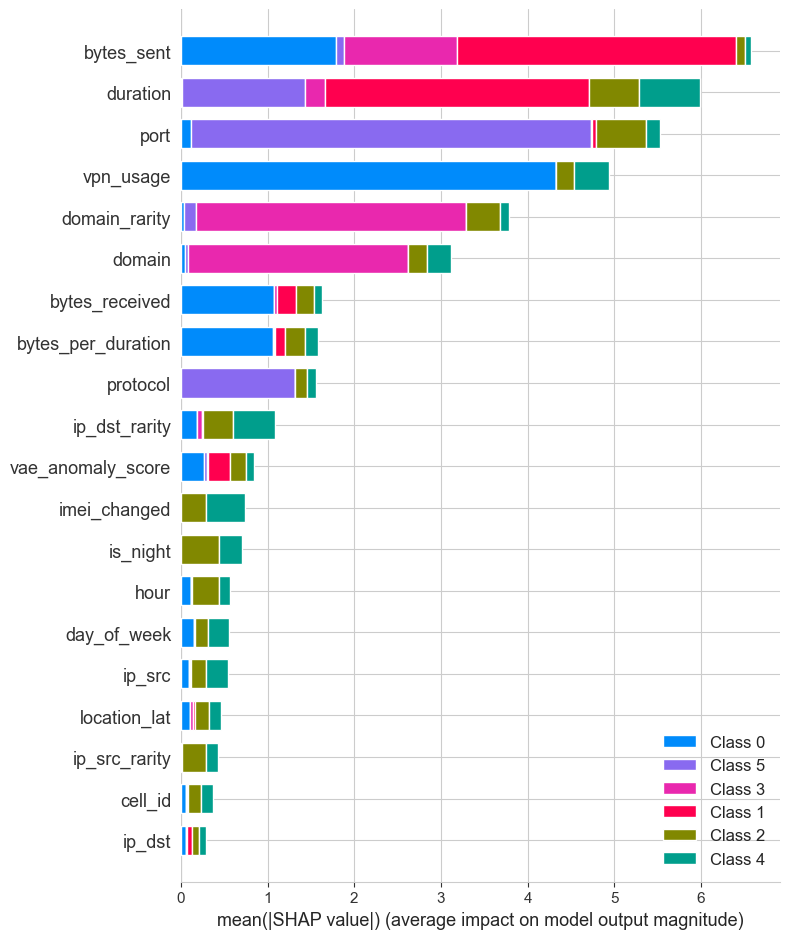

In [31]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import joblib

print("\n--- Training 'v4' Hybrid Model ---")

# 1. Clean Up the Data
# We must ensure X has NO strings.
# We explicitly drop 'anomaly_name' (created for plotting) and the target.
cols_to_drop = [TARGET_COLUMN, 'anomaly_name'] 
X = df_v4.drop(columns=cols_to_drop, errors='ignore')

# 2. Prepare the Target (y)
# Ensure it is encoded (numbers), not strings (names)
if df_v4[TARGET_COLUMN].dtype == 'object':
    print("Encoding target variable...")
    target_encoder_v4 = LabelEncoder()
    y = target_encoder_v4.fit_transform(df_v4[TARGET_COLUMN])
else:
    # If already encoded, just use it
    y = df_v4[TARGET_COLUMN]

print(f"Training Features: {X.shape[1]}")
print(f"Feature Names: {X.columns.tolist()}")

# 3. Train/Test Split
# We stratify to keep the fraud ratio consistent
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. SMOTE (Fix Class Imbalance)
print("Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 5. Train XGBoost (The Judge)
print("Training XGBoost v4...")
model_v4 = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=len(np.unique(y)), 
    n_estimators=200, 
    max_depth=5, 
    learning_rate=0.1,
    random_state=42
)
model_v4.fit(X_train_resampled, y_train_resampled)

print("v4 Hybrid Model Trained Successfully.")

# 6. Check Feature Importance (Optional)
# See if the model likes your new VAE/GNN features
import shap
try:
    explainer = shap.TreeExplainer(model_v4)
    shap_values = explainer.shap_values(X_test)
    print("Generating Feature Importance Plot...")
    shap.summary_plot(shap_values, X_test, plot_type="bar")
except Exception as e:
    print(f"Could not generate SHAP plot: {e}")

In [33]:
import joblib

print("--- Saving 'v4' Hybrid Model Artifacts ---")

# 1. Define 'model_columns' (This was the missing step!)
# We grab the column names from the X dataframe we used for training
model_columns = X.columns.tolist()

# 2. Save the new Hybrid XGBoost Model
joblib.dump(model_v4, 'v4_xgboost_hybrid_model.joblib')

# 3. Save the VAE (Autoencoder) Model (if you have one)
# joblib.dump(autoencoder, 'v4_vae_model.joblib') 

# 4. Save the column list (Now it is defined!)
joblib.dump(model_columns, 'v4_model_columns.joblib')

# 5. Save the Encoders (Re-using v3 encoders is usually fine if data didn't change)
# If you created new encoders for v4, save those. Otherwise, save the existing ones.
if 'target_encoder_v4' in globals():
    joblib.dump(target_encoder_v4, 'v4_target_encoder.joblib')
else:
    joblib.dump(target_encoder, 'v4_target_encoder.joblib')

joblib.dump(feature_encoders, 'v4_feature_encoders.joblib')

# 6. Save Rarity Maps (Critical for the 'v3' features inside v4)
if 'rarity_maps' in globals():
    joblib.dump(rarity_maps, 'v4_rarity_maps.joblib')

print("v4 Artifacts Saved Successfully.")

--- Saving 'v4' Hybrid Model Artifacts ---
v4 Artifacts Saved Successfully.


--- Evaluating v4 Hybrid Model (Behavioral + VAE) ---

--- Classification Report ---
                 precision    recall  f1-score   support

     DATA_EXFIL       0.98      0.96      0.97       224
       MASS_SMS       1.00      1.00      1.00       405
         Normal       0.99      1.00      1.00     14369
OTP_REDIRECTION       1.00      1.00      1.00       223
       SIM_SWAP       0.82      0.54      0.65       139
     VOIP_SPOOF       1.00      1.00      1.00       258

       accuracy                           0.99     15618
      macro avg       0.97      0.92      0.94     15618
   weighted avg       0.99      0.99      0.99     15618


--- Confusion Matrix ---


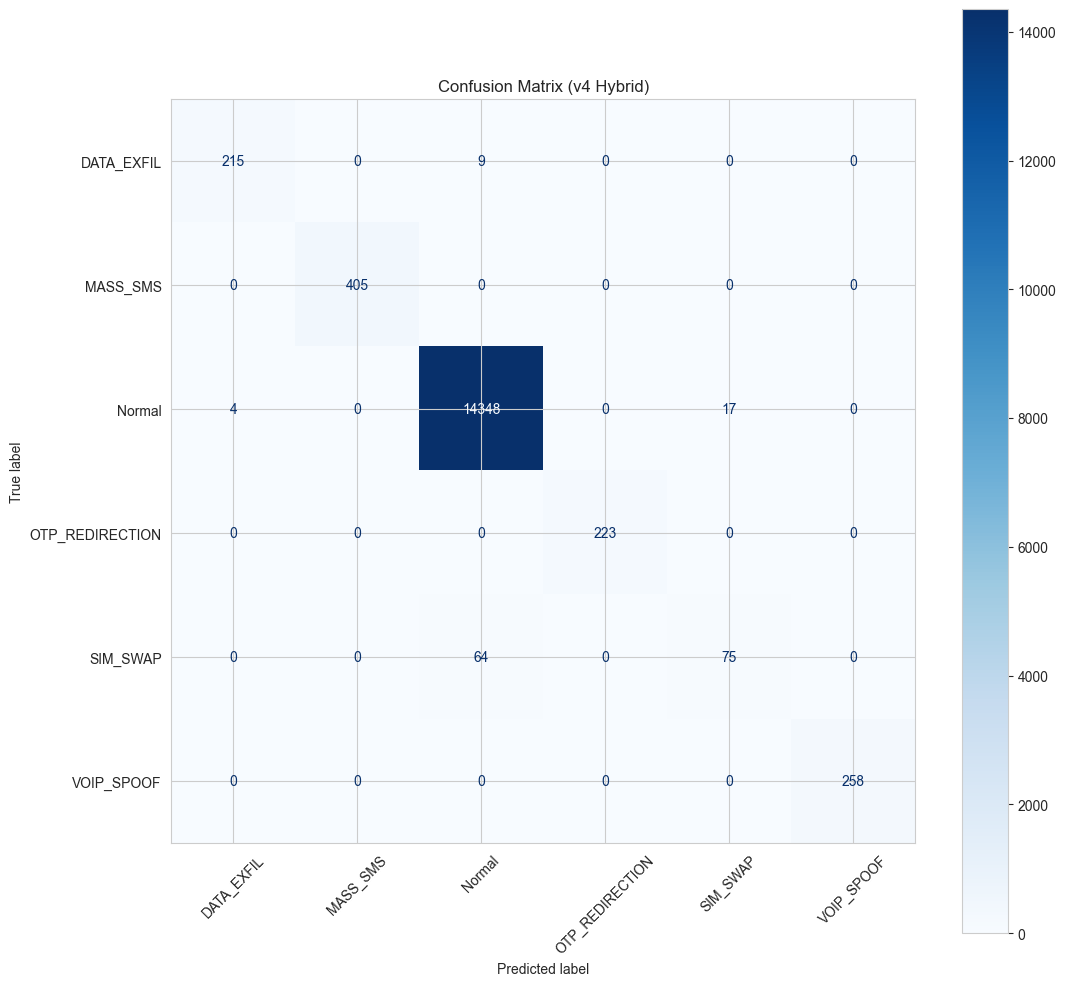


--- Feature Importance (SHAP) ---
Checking if 'vae_anomaly_score' is contributing...


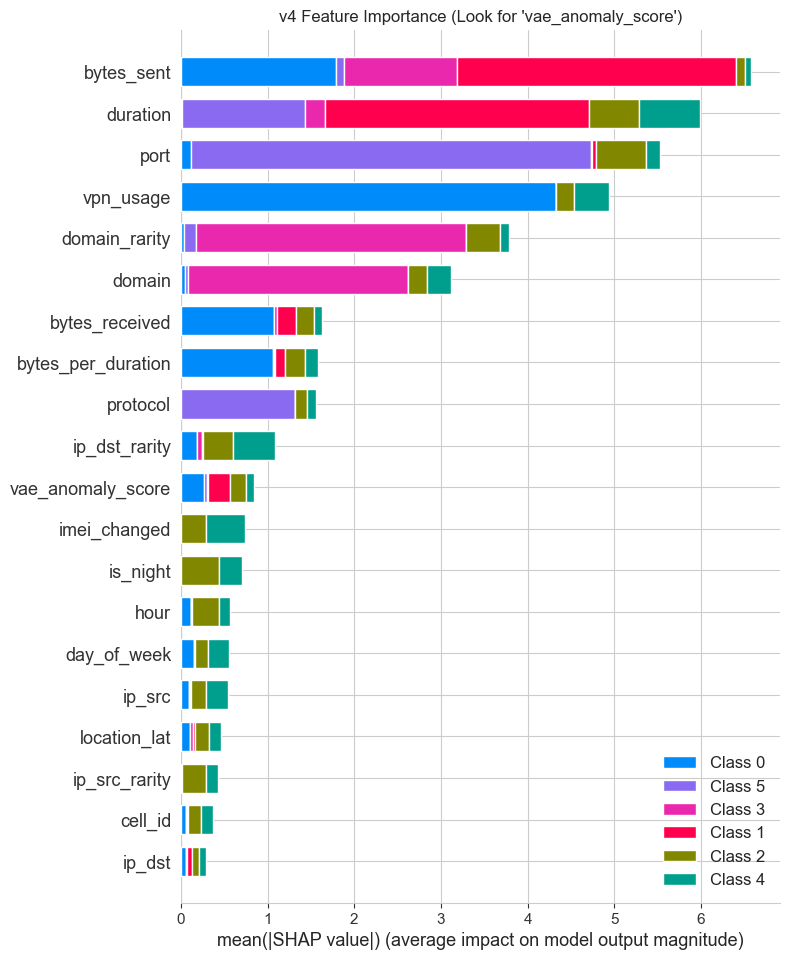


--- VAE Score Analysis on Test Set ---


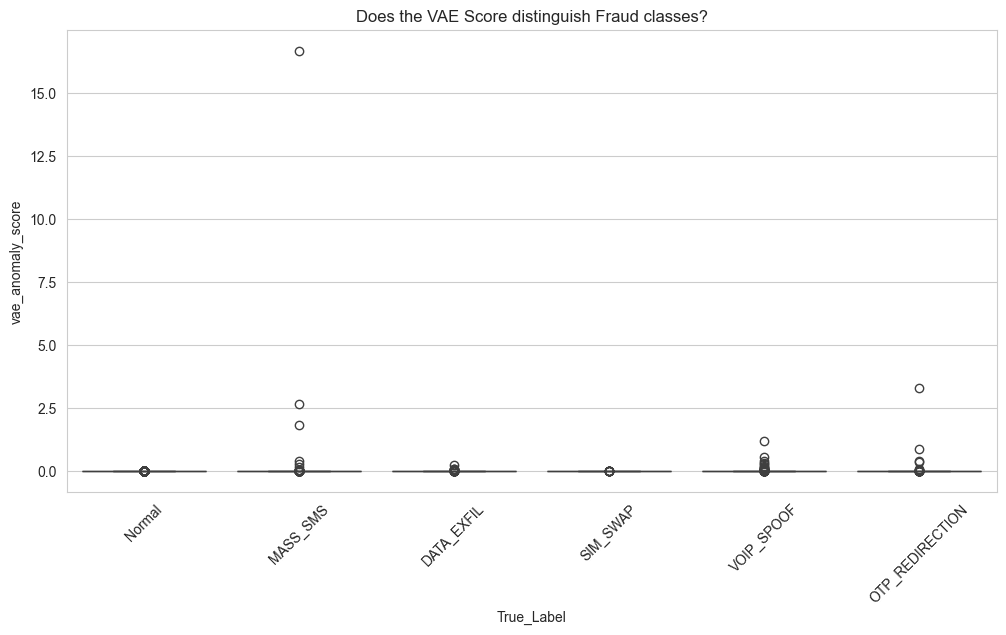

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import shap

print("--- Evaluating v4 Hybrid Model (Behavioral + VAE) ---")

# 1. Make Predictions
y_pred_v4 = model_v4.predict(X_test)

# 2. Get readable labels
# We try to find the correct encoder from previous steps
if 'target_encoder_v4' in globals():
    encoder = target_encoder_v4
elif 'target_encoder' in globals():
    encoder = target_encoder
else:
    print("Warning: Target encoder not found. Using raw numbers.")
    encoder = None

if encoder:
    y_test_labels = encoder.inverse_transform(y_test)
    y_pred_labels = encoder.inverse_transform(y_pred_v4)
    labels = encoder.classes_
else:
    y_test_labels = y_test
    y_pred_labels = y_pred_v4
    labels = sorted(list(set(y_test)))

# 3. Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test_labels, y_pred_labels))

# 4. Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(cmap='Blues', ax=ax)
plt.xticks(rotation=45)
plt.title("Confusion Matrix (v4 Hybrid)")
plt.show()

# 5. CRITICAL: Feature Importance (Did the VAE help?)
# We use SHAP to see if 'vae_anomaly_score' is being used by the model
print("\n--- Feature Importance (SHAP) ---")
print("Checking if 'vae_anomaly_score' is contributing...")

try:
    explainer = shap.TreeExplainer(model_v4)
    shap_values = explainer.shap_values(X_test)
    
    # Create the summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title("v4 Feature Importance (Look for 'vae_anomaly_score')")
    plt.show()
    
    # Detailed Beeswarm plot (Optional, uncomment if needed)
    # shap.summary_plot(shap_values, X_test)
    
except Exception as e:
    print(f"Could not generate SHAP plot: {e}")

# 6. Deep Dive: VAE Score Effectiveness
# Let's verify if the VAE score actually separates Normal from Fraud in the TEST set
print("\n--- VAE Score Analysis on Test Set ---")
test_df_analysis = X_test.copy()
test_df_analysis['True_Label'] = y_test_labels

plt.figure(figsize=(12, 6))
sns.boxplot(data=test_df_analysis, x='True_Label', y='vae_anomaly_score')
plt.title("Does the VAE Score distinguish Fraud classes?")
plt.xticks(rotation=45)
plt.show()

In [36]:
import torch
from torch_geometric.data import HeteroData
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("--- Phase 3 (PyG): Graph Construction ---")

# 1. FORCE RELOAD of Raw Data to get 'user_id' back
# We cannot use the previous 'df_raw' because it might have dropped user_id
print("Reloading raw data to recover ID columns...")
df_full_raw = pd.read_csv('../data/ipdr_synthetic_fixed.csv')

# 2. Align with our current Training Data
# We must ensure we are building the graph for the SAME rows we are training on.
# We use the index of df_v4 (or df_final) to filter the raw data.
# Note: Ensure 'df_v4' is the dataframe you prepared in the VAE step.
if 'df_v4' in globals():
    target_index = df_v4.index
elif 'df_final' in globals():
    target_index = df_final.index
else:
    raise ValueError("Cannot find df_v4 or df_final. Please run VAE step first.")

data_graph = df_full_raw.loc[target_index].copy()

print(f"Graph Data Shape: {data_graph.shape} (Should match v4 shape)")

# 3. Encode Nodes
print("Encoding Node IDs...")
user_le = LabelEncoder()
ip_le = LabelEncoder()
imei_le = LabelEncoder()

# Create index columns for the graph
# We use .astype(str) to handle any mixed types safely
data_graph['user_idx'] = user_le.fit_transform(data_graph['user_id'].astype(str))
data_graph['ip_idx'] = ip_le.fit_transform(data_graph['ip_src'].astype(str))
data_graph['imei_idx'] = imei_le.fit_transform(data_graph['imei'].astype(str))

# 4. Create the HeteroData Object
data = HeteroData()

# --- A. Define Node Features (x) ---
# User Features: Feed in the rich features we engineered (v3 + VAE)
# We select numeric columns from df_v4 (or df_final) that align with these rows
feature_cols = ['bytes_per_duration', 'is_night', 'vae_anomaly_score']

# Ensure these columns exist
available_feats = [c for c in feature_cols if c in df_v4.columns]
if not available_feats:
    print("Warning: VAE features not found. Using dummy features for Users.")
    data['user'].x = torch.ones(len(user_le.classes_), 1)
else:
    print(f"Using User Features: {available_feats}")
    # Convert dataframe columns to PyTorch tensor
    # We use df_v4 values that correspond to these rows
    user_feat_tensor = torch.tensor(df_v4[available_feats].values, dtype=torch.float)
    data['user'].x = user_feat_tensor

# IP/IMEI Features: Just ones (identity/constant) because we have no external info about them
data['ip'].x = torch.ones(len(ip_le.classes_), 1)
data['imei'].x = torch.ones(len(imei_le.classes_), 1)

# --- B. Define Edge Indices (Connectivity) ---
print("Building Edges...")

# Connection 1: User <-> IP
user_ip_source = torch.tensor(data_graph['user_idx'].values, dtype=torch.long)
user_ip_target = torch.tensor(data_graph['ip_idx'].values, dtype=torch.long)
data['user', 'uses_ip', 'ip'].edge_index = torch.stack([user_ip_source, user_ip_target])

# Connection 2: User <-> IMEI
user_imei_source = torch.tensor(data_graph['user_idx'].values, dtype=torch.long)
user_imei_target = torch.tensor(data_graph['imei_idx'].values, dtype=torch.long)
data['user', 'uses_device', 'imei'].edge_index = torch.stack([user_imei_source, user_imei_target])

print("Graph Constructed Successfully!")
print(data)

--- Phase 3 (PyG): Graph Construction ---
Reloading raw data to recover ID columns...
Graph Data Shape: (78086, 20) (Should match v4 shape)
Encoding Node IDs...
Using User Features: ['bytes_per_duration', 'is_night', 'vae_anomaly_score']
Building Edges...
Graph Constructed Successfully!
HeteroData(
  user={ x=[78086, 3] },
  ip={ x=[65775, 1] },
  imei={ x=[2000, 1] },
  (user, uses_ip, ip)={ edge_index=[2, 78086] },
  (user, uses_device, imei)={ edge_index=[2, 78086] }
)


In [38]:
import torch
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, to_hetero
import torch.nn.functional as F

print("--- Phase 3 Fix: Adding Reverse Edges ---")

# 1. Assuming 'data' was created in your previous step...
# We need to add edges pointing BACK to the user so the User node gets updated.

# Reverse Connection 1: IP -> User
# We take the existing (User->IP) indices and flip them (row 1 becomes row 0)
edge_index_user_ip = data['user', 'uses_ip', 'ip'].edge_index
data['ip', 'rev_uses_ip', 'user'].edge_index = torch.stack([edge_index_user_ip[1], edge_index_user_ip[0]])

# Reverse Connection 2: IMEI -> User
edge_index_user_imei = data['user', 'uses_device', 'imei'].edge_index
data['imei', 'rev_uses_device', 'user'].edge_index = torch.stack([edge_index_user_imei[1], edge_index_user_imei[0]])

print("Reverse edges added. Metadata:", data.metadata())

# 2. Define the GNN Model (Same as before)
class FraudGNN(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv((-1, -1), hidden_channels)
        self.conv2 = SAGEConv((-1, -1), out_channels)

    def forward(self, x, edge_index):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = x.relu()
        # Layer 2
        x = self.conv2(x, edge_index)
        return x

# 3. Initialize & Convert
model = FraudGNN(hidden_channels=64, out_channels=32)

# IMPORTANT: Now that we have edges pointing TO the user, 
# 'to_hetero' will successfully generate an update path for the 'user' node type.
model = to_hetero(model, data.metadata(), aggr='sum')

print("GNN Model Architecture Defined Successfully!")

--- Phase 3 Fix: Adding Reverse Edges ---
Reverse edges added. Metadata: (['user', 'ip', 'imei'], [('user', 'uses_ip', 'ip'), ('user', 'uses_device', 'imei'), ('ip', 'rev_uses_ip', 'user'), ('imei', 'rev_uses_device', 'user')])
GNN Model Architecture Defined Successfully!


In [39]:
print("--- Training GNN ---")

# 1. Prepare Target
# We only have labels for 'user' nodes (each row is a user event)
# Convert y (targets) to tensor
y_tensor = torch.tensor(y.values, dtype=torch.long) 
# Note: Ensure y is encoded 0..N

# 2. Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 3. Training Loop
model.train()
for epoch in range(51): # 50 epochs
    optimizer.zero_grad()
    
    # Forward Pass
    # output_dict contains embeddings for {'user', 'ip', 'imei'}
    output_dict = model(data.x_dict, data.edge_index_dict)
    
    # We only care about predicting for 'user' nodes
    user_output = output_dict['user']
    
    # Calculate Loss (CrossEntropy for classification)
    loss = F.cross_entropy(user_output, y_tensor)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

print("GNN Training Complete.")

--- Training GNN ---
Epoch 0 | Loss: 2409.3142
Epoch 10 | Loss: 995.7957
Epoch 20 | Loss: 591.4979
Epoch 30 | Loss: 325.7426
Epoch 40 | Loss: 242.2711
Epoch 50 | Loss: 147.8147
GNN Training Complete.


In [40]:
from sklearn.metrics import classification_report
import torch

print("--- Evaluating GNN Expert (Standalone) ---")

model.eval()
with torch.no_grad():
    # Get the raw output (logits) for users
    output_dict = model(data.x_dict, data.edge_index_dict)
    user_logits = output_dict['user']
    
    # Convert logits to class predictions (0, 1, 2...)
    # dim=1 means we pick the class with the highest score
    user_preds = user_logits.argmax(dim=1).numpy()

# Get true labels (ensure they are numpy)
y_true = y.values 

# If you have an encoder, map numbers back to names for readability
if 'target_encoder_final' in globals():
    target_names = target_encoder_final.classes_
    print(classification_report(y_true, user_preds, target_names=target_names))
else:
    print(classification_report(y_true, user_preds))

print("Note: The GNN might be weaker than XGBoost on 'simple' features, but stronger on 'network' features.")

--- Evaluating GNN Expert (Standalone) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1121
           1       0.00      0.00      0.00      2026
           2       0.92      1.00      0.96     71840
           3       0.00      0.00      0.00      1117
           4       0.00      0.00      0.00       695
           5       0.00      0.00      0.00      1287

    accuracy                           0.92     78086
   macro avg       0.15      0.17      0.16     78086
weighted avg       0.85      0.92      0.88     78086

Note: The GNN might be weaker than XGBoost on 'simple' features, but stronger on 'network' features.


C:\Users\bansa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bansa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bansa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

In [41]:
print("--- Extracting Graph Embeddings ---")

# 1. Get the final embeddings (Forward pass without gradients)
model.eval()
with torch.no_grad():
    output_dict = model(data.x_dict, data.edge_index_dict)
    user_embeddings = output_dict['user'].numpy()

print(f"Extracted User Embeddings Shape: {user_embeddings.shape}")

# 2. Add to DataFrame
# We create 32 new columns: gnn_0, gnn_1, ... gnn_31
embedding_cols = [f'gnn_emb_{i}' for i in range(user_embeddings.shape[1])]
df_gnn_features = pd.DataFrame(user_embeddings, columns=embedding_cols, index=df_v4.index)

# 3. Merge
df_v4_final = pd.concat([df_v4, df_gnn_features], axis=1)

print("Merged GNN Features into 'df_v4_final'.")
print(f"Final Data Shape: {df_v4_final.shape}")

--- Extracting Graph Embeddings ---
Extracted User Embeddings Shape: (78086, 32)
Merged GNN Features into 'df_v4_final'.
Final Data Shape: (78086, 55)


In [42]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import joblib

print("--- Phase 5: Training Final Hybrid Model (v5) ---")

# 1. Prepare Data
# Drop target and non-numeric columns (like names created for plots)
# We assume df_v4_final contains: v3 features + vae_score + gnn_embeddings
cols_to_drop = ['anomaly_type', 'anomaly_name'] 
X = df_v4_final.drop(columns=cols_to_drop, errors='ignore')

# Handle Target
# Ensure it's encoded 0..N
if df_v4_final['anomaly_type'].dtype == 'object':
    target_encoder_v5 = LabelEncoder()
    y = target_encoder_v5.fit_transform(df_v4_final['anomaly_type'])
else:
    y = df_v4_final['anomaly_type']
    # If you used a previous encoder, just reuse it for labels later
    target_encoder_v5 = target_encoder  # Reuse v3/v4 encoder if available

# 2. Split (Stratified to keep fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. SMOTE (Fix Imbalance)
print("Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Train XGBoost v5
print("Training XGBoost v5 (Judge)...")
model_v5 = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=len(set(y)), 
    n_estimators=200, 
    max_depth=5, 
    learning_rate=0.1,
    n_jobs=-1
)
model_v5.fit(X_train_res, y_train_res)
print("v5 Training Complete.")

# 5. Save Artifacts (Optional but recommended)
joblib.dump(model_v5, 'v5_xgboost_hybrid.joblib')
joblib.dump(X.columns.tolist(), 'v5_model_columns.joblib')
print("v5 Artifacts Saved.")

--- Phase 5: Training Final Hybrid Model (v5) ---
Applying SMOTE...
Training XGBoost v5 (Judge)...
v5 Training Complete.
v5 Artifacts Saved.



--- Evaluating Final Hybrid Model ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       224
           1       1.00      1.00      1.00       405
           2       1.00      1.00      1.00     14369
           3       1.00      1.00      1.00       223
           4       0.87      0.58      0.69       139
           5       1.00      1.00      1.00       258

    accuracy                           0.99     15618
   macro avg       0.97      0.92      0.94     15618
weighted avg       0.99      0.99      0.99     15618



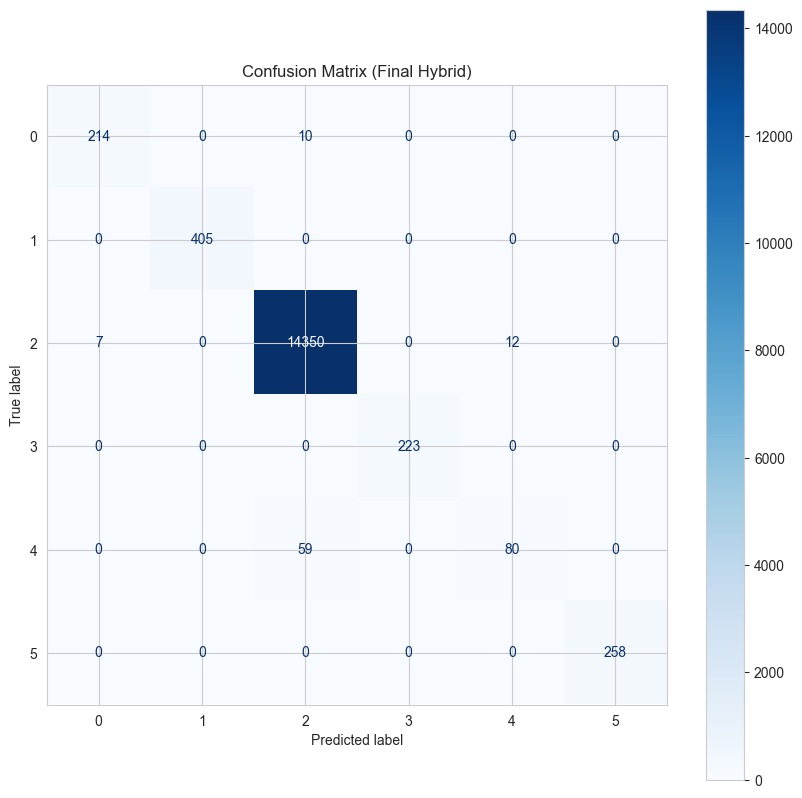

Generating Feature Importance Plot...


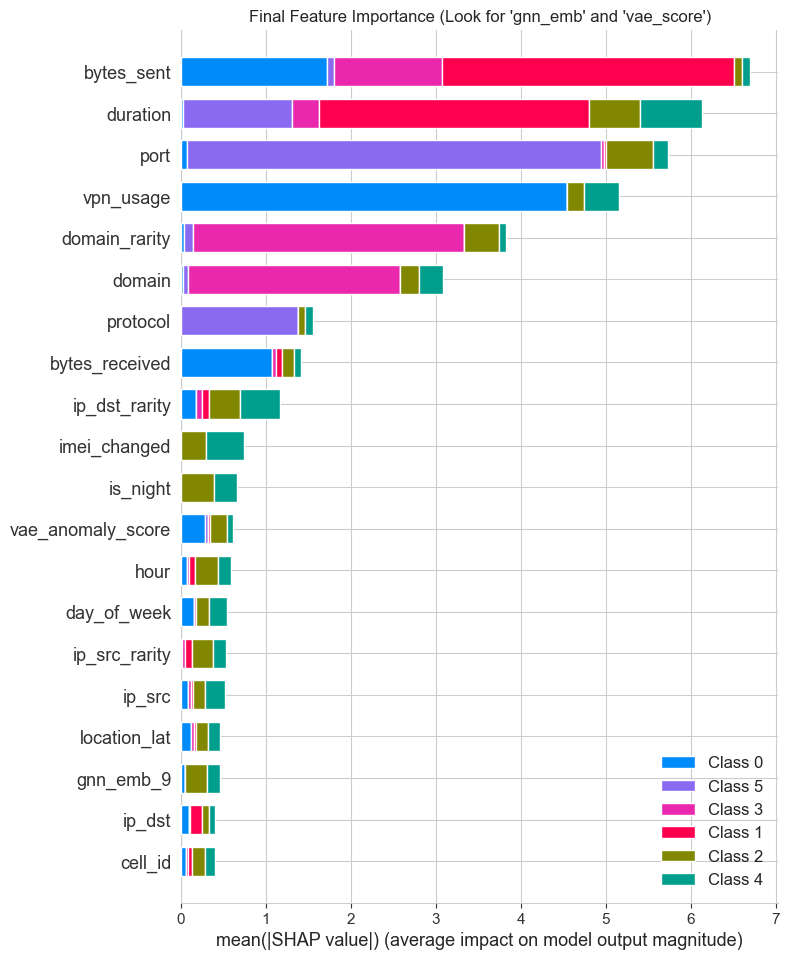

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import shap

print("\n--- Evaluating Final Hybrid Model ---")

# 1. Predictions
y_pred = model_v5.predict(X_test)

# 2. Readable Reports
if 'target_encoder_final' in globals():
    t_enc = target_encoder_final
    y_test_labels = t_enc.inverse_transform(y_test)
    y_pred_labels = t_enc.inverse_transform(y_pred)
    labels = t_enc.classes_
else:
    # Fallback if you used a different encoder name
    y_test_labels = y_test
    y_pred_labels = y_pred
    labels = None

print(classification_report(y_test_labels, y_pred_labels))

# 3. Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix (Final Hybrid)")
plt.show()

# 4. Feature Importance (Did GNN help?)
# We want to see 'gnn_emb_...' in the top features
print("Generating Feature Importance Plot...")
try:
    explainer = shap.TreeExplainer(model_v5)
    shap_values = explainer.shap_values(X_test)
    
    plt.figure(figsize=(10, 12))
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title("Final Feature Importance (Look for 'gnn_emb' and 'vae_score')")
    plt.show()
except Exception as e:
    print(f"SHAP Error: {e}")

--- Phase 6: Explainable AI (The 'Glass Box') ---
Initializing SHAP Explainer...

[A] Global Feature Importance
This chart answers: 'Which expert is the most trustworthy?'


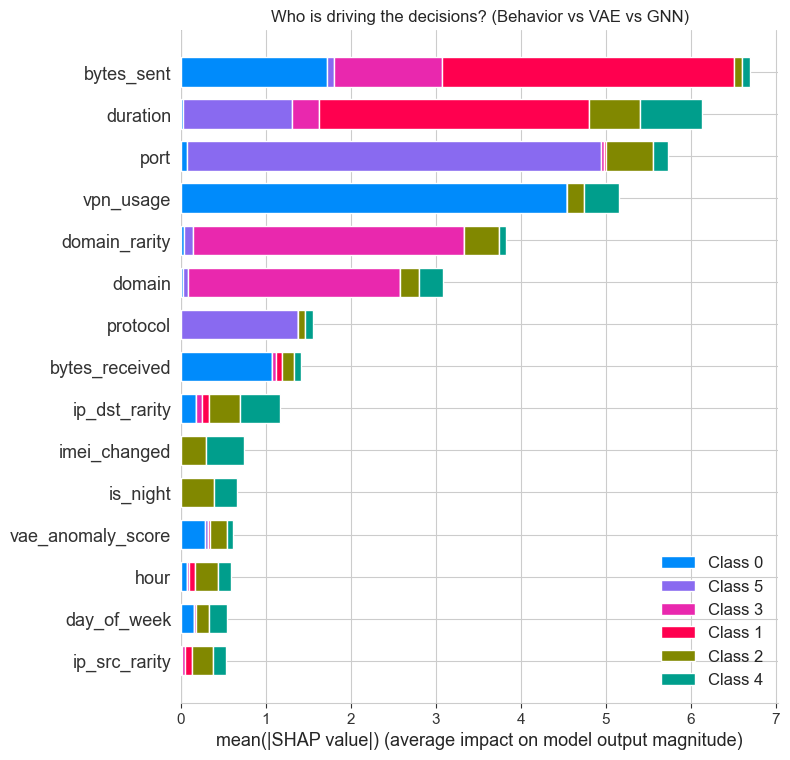

Detailed View (Red = High Value, Blue = Low Value):


<Figure size 1200x800 with 0 Axes>

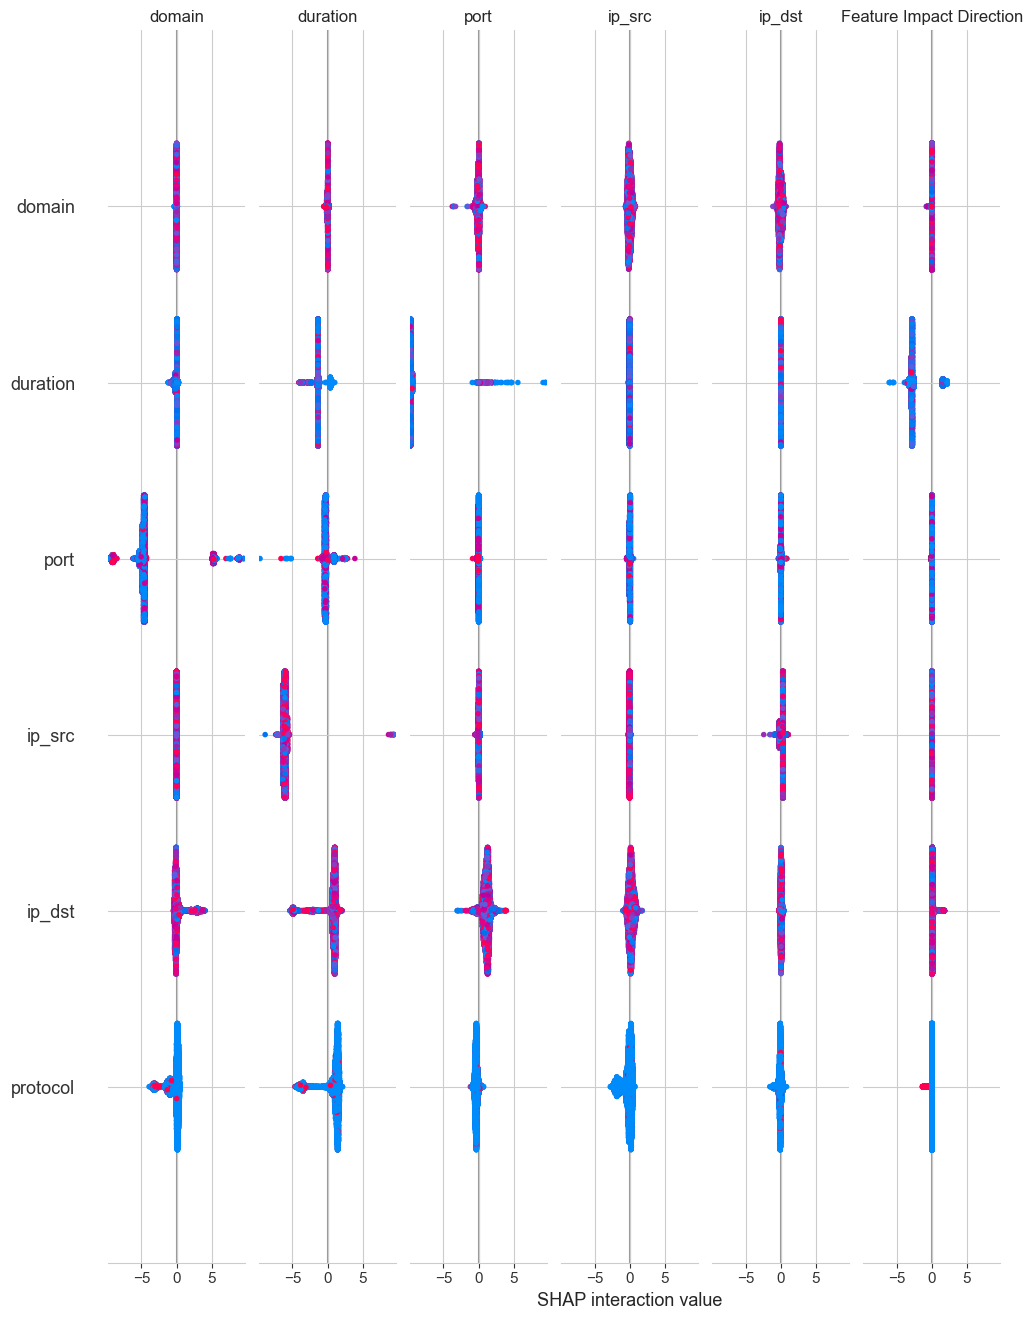


[B] Local Explanation (Autopsy of a specific Alert)
This chart answers: 'Why did we flag THIS specific user?'
Analyzing Test Record #20 (Predicted: SIM_SWAP)
Could not generate local plot: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (53, 6)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.


<Figure size 1000x600 with 0 Axes>

In [44]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("--- Phase 6: Explainable AI (The 'Glass Box') ---")

# 1. Initialize the Explainer
# XGBoost is a tree model, so we use TreeExplainer (very fast)
print("Initializing SHAP Explainer...")
explainer = shap.TreeExplainer(model_v5)
shap_values = explainer.shap_values(X_test)

# ---------------------------------------------------------
# A. GLOBAL EXPLANATION (The "Satellite View")
# ---------------------------------------------------------
print("\n[A] Global Feature Importance")
print("This chart answers: 'Which expert is the most trustworthy?'")

plt.figure(figsize=(12, 8))
# max_display=15: Show top 15 features
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.title("Who is driving the decisions? (Behavior vs VAE vs GNN)")
plt.show()

# Detailed Beeswarm Plot
print("Detailed View (Red = High Value, Blue = Low Value):")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("Feature Impact Direction")
plt.show()


# ---------------------------------------------------------
# B. LOCAL EXPLANATION (The "Microscope View")
# ---------------------------------------------------------
print("\n[B] Local Explanation (Autopsy of a specific Alert)")
print("This chart answers: 'Why did we flag THIS specific user?'")

# Let's find a successful SIM_SWAP detection to analyze
# 1. Find the column index for 'SIM_SWAP' in the target encoder
# (Adjust 'SIM_SWAP' string if your labels are different)
try:
    if 'target_encoder_v5' in globals():
        target_names = target_encoder_v5.classes_
        sim_swap_idx = np.where(target_names == 'SIM_SWAP')[0][0]
    else:
        # Fallback: Guessing index based on previous reports (usually 4 or 5)
        # You might need to change this number manually if the plot looks wrong
        sim_swap_idx = 4 
        print(f"Warning: Encoder not found, assuming SIM_SWAP is class index {sim_swap_idx}")

    # 2. Find a test record that was PREDICTED as SIM_SWAP
    y_pred_v5 = model_v5.predict(X_test)
    sim_swap_hits = np.where(y_pred_v5 == sim_swap_idx)[0]
    
    if len(sim_swap_hits) > 0:
        # Pick the first one
        sample_idx = sim_swap_hits[0]
        print(f"Analyzing Test Record #{sample_idx} (Predicted: SIM_SWAP)")
        
        # 3. Generate the Waterfall Plot (The Industry Standard for Explanations)
        # Note: shap_values is a list of arrays (one for each class). 
        # We need the array for the SIM_SWAP class.
        if isinstance(shap_values, list):
            # For multi-class, SHAP returns a list
            sv = shap_values[sim_swap_idx][sample_idx]
        else:
            # For binary, it returns one array
            sv = shap_values[sample_idx]
            
        # We use the Explainer's expected value for the start of the waterfall
        if isinstance(explainer.expected_value, list) or isinstance(explainer.expected_value, np.ndarray):
             base_val = explainer.expected_value[sim_swap_idx]
        else:
             base_val = explainer.expected_value

        # Create Explanation Object for the plot
        explanation = shap.Explanation(
            values=sv,
            base_values=base_val,
            data=X_test.iloc[sample_idx],
            feature_names=X_test.columns
        )
        
        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(explanation, max_display=10, show=False)
        plt.title(f"Why was Record {sample_idx} flagged?")
        plt.show()
        
    else:
        print("No SIM_SWAP predictions found in X_test to analyze.")

except Exception as e:
    print(f"Could not generate local plot: {e}")

In [45]:
import pandas as pd
import numpy as np
import random

print("--- Phase 1: Generating 'Dirty' Realistic Data ---")

# 1. Load the Perfect Data
df_clean = pd.read_csv('../data/ipdr_synthetic_fixed.csv')
print(f"Loaded Clean Data: {len(df_clean)} rows.")

# Create a copy to mess up
df_dirty = df_clean.copy()

# --- INJECTION 1: Missing Values (The "Null" Problem) ---
# Real sensors often fail to report an IMEI or Cell ID.
# We will randomly set 5% of these to NaN (Null).
columns_to_corrupt = ['imei', 'cell_id', 'ip_src']
noise_level = 0.05

for col in columns_to_corrupt:
    # Generate a mask of True/False
    mask = np.random.rand(len(df_dirty)) < noise_level
    df_dirty.loc[mask, col] = np.nan
print(f"  - Injected {noise_level*100}% Missing Values (NaN) into {columns_to_corrupt}")

# --- INJECTION 2: Categorical Typos (The "Messy String" Problem) ---
# 'TCP' vs 'tcp' vs 'Tcp '. Machines hate this.
# We will mess up the 'protocol' column.
def dirty_string(text):
    if pd.isna(text): return text
    r = random.random()
    if r < 0.02: return text.lower()       # "tcp"
    if r < 0.04: return text + " "         # "TCP " (trailing space)
    return text

df_dirty['protocol'] = df_dirty['protocol'].apply(dirty_string)
print(f"  - Injected Case/Whitespace errors into 'protocol'.")

# --- INJECTION 3: Numerical Glitches (The "Outlier" Problem) ---
# Sometimes duration is -1 (bug) or 9999999 (overflow).
# We will corrupt 'duration'.
mask_neg = np.random.rand(len(df_dirty)) < 0.01 # 1% Negative values
df_dirty.loc[mask_neg, 'duration'] = -5

mask_huge = np.random.rand(len(df_dirty)) < 0.01 # 1% Massive outliers
df_dirty.loc[mask_huge, 'bytes_sent'] = df_dirty['bytes_sent'] * 100
print(f"  - Injected negative durations and massive byte spikes.")

# --- INJECTION 4: Timestamp Jitter (The "Lag" Problem) ---
# Real events don't arrive perfectly in order.
# We won't re-sort them (v3 pipeline does that), but we will mess up the format
# by adding a few rows with "bad" timestamp strings if we wanted to be really mean.
# For now, let's keep timestamp valid but verify our pipeline handles sort correctly.

# --- SAVE THE DIRTY DATA ---
df_dirty.to_csv('../data/ipdr_data_dirty.csv', index=False)
print("\n--- Success! Saved 'ipdr_data_dirty.csv' ---")
print("This dataset is now full of holes, typos, and garbage.")
print(df_dirty[['imei', 'protocol', 'duration', 'bytes_sent']].sample(10))

--- Phase 1: Generating 'Dirty' Realistic Data ---
Loaded Clean Data: 78086 rows.
  - Injected 5.0% Missing Values (NaN) into ['imei', 'cell_id', 'ip_src']
  - Injected Case/Whitespace errors into 'protocol'.
  - Injected negative durations and massive byte spikes.

--- Success! Saved 'ipdr_data_dirty.csv' ---
This dataset is now full of holes, typos, and garbage.
                   imei protocol    duration  bytes_sent
71471  00eeaad6f9da2862      TCP  255.022214       72376
8769   7a2b347c17b8ce5f      TCP   26.213344        9882
72622               NaN      TCP    1.000000          50
35375  ece0c10f5613b062      TCP    7.462900       15196
36319  841cb68535763f82      TCP   32.926577       10641
24513  677630e57e949249      TCP   80.030498       43088
61631  f6293f17a597db3f      UDP   19.724685       84520
60473  622b00bc7aae9b26      TCP   16.729039       11583
28427  795e59eb7d5346c7      TCP  113.486995      268504
23817  311bbba1b561280d      TCP   18.736224       11109


In [46]:
print("\n--- Phase 2: Stress Testing the v3 Pipeline ---")

# Load artifacts (Simulation of Production)
try:
    feature_encoders_v3 = joblib.load('feature_encoders_v3.joblib')
    rarity_maps_v3 = joblib.load('rarity_maps_v3.joblib')
    model_columns_v3 = joblib.load('model_columns_v3.joblib')
    model_v3 = joblib.load('xgboost_fraud_model_v3.joblib')
except:
    print("Run the previous training cells first to save artifacts!")

# Load DIRTY data
df_test_dirty = pd.read_csv('../data/ipdr_data_dirty.csv')

# --- APPLY PREPROCESSING (Is it Robust?) ---

try:
    # 1. Handle NaNs in Categoricals BEFORE encoding
    # (Production code must fill NaNs with a placeholder like 'UNKNOWN')
    categorical_cols = ['domain', 'ip_src', 'ip_dst', 'protocol', 'cell_id', 'imei']
    for col in categorical_cols:
        if col in df_test_dirty.columns:
            df_test_dirty[col] = df_test_dirty[col].fillna('UNKNOWN').astype(str)

    # 2. Fix Typos (Normalization)
    # Good pipelines force lowercase or strip whitespace
    df_test_dirty['protocol'] = df_test_dirty['protocol'].str.upper().str.strip()

    # 3. Handle Numerical Errors
    # Clip negative durations to 0
    df_test_dirty['duration'] = df_test_dirty['duration'].clip(lower=0)
    
    # 4. Run Standard v3 Logic
    print("Running v3 Feature Engineering...")
    df_test_dirty['timestamp'] = pd.to_datetime(df_test_dirty['timestamp'], format='mixed')
    df_test_dirty = df_test_dirty.sort_values(by=['imsi', 'timestamp'])
    
    # Stateful Logic
    df_test_dirty['previous_imei'] = df_test_dirty.groupby('imsi')['imei'].shift(1)
    df_test_dirty['imei_changed'] = (df_test_dirty['imei'] != df_test_dirty['previous_imei']).astype(int).fillna(0)
    
    # Stateless Logic
    df_test_dirty['hour'] = df_test_dirty['timestamp'].dt.hour
    df_test_dirty['day_of_week'] = df_test_dirty['timestamp'].dt.dayofweek
    df_test_dirty['is_night'] = ((df_test_dirty['hour'] >= 0) & (df_test_dirty['hour'] <= 6)).astype(int)
    df_test_dirty['vpn_usage'] = df_test_dirty['vpn_usage'].astype(int)
    df_test_dirty['bytes_per_duration'] = (df_test_dirty['bytes_sent'] + df_test_dirty['bytes_received']) / (df_test_dirty['duration'] + 1)

    # Encoding (The Dangerous Part)
    feature_cols = ['domain', 'ip_src', 'ip_dst', 'protocol', 'cell_id'] # imei is usually dropped
    for col in feature_cols:
        le = feature_encoders_v3.get(col)
        if le:
            # Safe Transform Logic
            # We map known labels, and set unknown to -1
            # 1. Get dictionary mapping from the encoder
            le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
            # 2. Map and fill unknown with -1
            df_test_dirty[col] = df_test_dirty[col].map(le_dict).fillna(-1)
            
            # Rarity Logic
            # If -1 (unknown), rarity should be 0 (or we can assume 0)
            df_test_dirty[f'{col}_rarity'] = df_test_dirty[col].apply(lambda x: rarity_maps_v3[col].get(x, 0))

    # Drop cleanup
    df_final_test = df_test_dirty.drop(columns=['event_id', 'user_id', 'imsi', 'imei', 'previous_imei', 'timestamp', 'runbook_id', 'is_fraud', 'location_lon', 'cell_id_rarity'], errors='ignore')
    
    # Predict
    # Filter only columns model expects
    df_final_test = df_final_test.reindex(columns=model_columns_v3, fill_value=0)
    
    preds = model_v3.predict(df_final_test)
    print("\nSUCCESS: The pipeline processed the dirty data without crashing.")
    print(f"Generated {len(preds)} predictions.")
    
except Exception as e:
    print(f"\nFAILURE: The pipeline crashed on dirty data.")
    print(f"Error: {e}")


--- Phase 2: Stress Testing the v3 Pipeline ---
Run the previous training cells first to save artifacts!
Running v3 Feature Engineering...

FAILURE: The pipeline crashed on dirty data.
Error: name 'feature_encoders_v3' is not defined


--- Starting Robust 'v3' Training on Dirty Data ---
Successfully loaded 78086 rows of DIRTY data.
Applying Safety Layer (Cleaning)...
  - Data cleaned (NaNs filled, strings normalized, negatives clipped).
Creating 'v3' stateful features...
Creating 'v2' stateless features...

--- Training Robust Model ---
Training on 78086 rows with 20 features.
Applying SMOTE...
Training XGBoost...
--- Training Complete ---

--- Evaluation on Dirty Test Set ---
                 precision    recall  f1-score   support

     DATA_EXFIL       0.96      0.96      0.96       224
       MASS_SMS       1.00      1.00      1.00       405
         Normal       0.99      0.99      0.99     14369
OTP_REDIRECTION       1.00      1.00      1.00       223
       SIM_SWAP       0.06      0.03      0.04       139
     VOIP_SPOOF       1.00      1.00      1.00       258

       accuracy                           0.99     15618
      macro avg       0.83      0.83      0.83     15618
   weighted avg       0.98      0.9

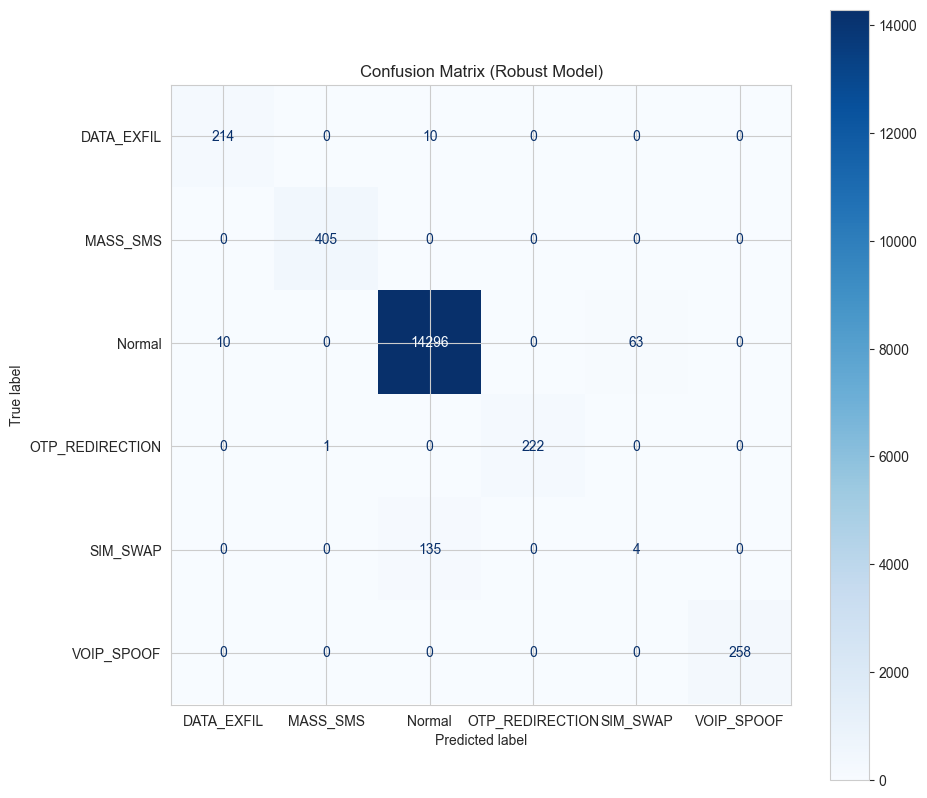

In [47]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- Starting Robust 'v3' Training on Dirty Data ---")

# --- 1. Load the Dirty Data ---
DATA_FILE = '../data/ipdr_data_dirty.csv'
TARGET_COLUMN = 'anomaly_type'
# We drop identifiers, plus the columns we know are garbage/leakage
DROP_COLUMNS = ['event_id', 'user_id', 'imsi', 'imei', 'runbook_id', 'is_fraud', 'location_lon', 'cell_id_rarity']

try:
    df_robust = pd.read_csv(DATA_FILE)
    print(f"Successfully loaded {len(df_robust)} rows of DIRTY data.")
except FileNotFoundError:
    print(f"Error: Data file not found at {DATA_FILE}")

# --- 2. The "Safety Layer" (Cleaning the Mess) ---
print("Applying Safety Layer (Cleaning)...")

# A. Fix Categorical NaNs & Typos
categorical_cols = ['domain', 'ip_src', 'ip_dst', 'protocol', 'cell_id', 'imei']
for col in categorical_cols:
    if col in df_robust.columns:
        # Fill missing with 'UNKNOWN'
        df_robust[col] = df_robust[col].fillna('UNKNOWN').astype(str)
        # Normalize strings (fix 'TCP ' vs 'tcp')
        df_robust[col] = df_robust[col].str.upper().str.strip()

# B. Fix Numerical Errors
# Clip negative durations to 0
if 'duration' in df_robust.columns:
    df_robust['duration'] = df_robust['duration'].clip(lower=0)
    # Optional: Handle massive outliers if needed, or let XGBoost handle them
    
# C. Handle Target NaNs (We can't train on unknown targets easily, usually we drop or assume Normal)
# Here we assume missing target = Normal
df_robust[TARGET_COLUMN] = df_robust[TARGET_COLUMN].fillna('Normal')

print("  - Data cleaned (NaNs filled, strings normalized, negatives clipped).")

# --- 3. Stateful v3 Feature Engineering ---
print("Creating 'v3' stateful features...")
# We must handle timestamp parsing carefully on dirty data
df_robust['timestamp'] = pd.to_datetime(df_robust['timestamp'], format='mixed', errors='coerce')
# Drop rows where timestamp entirely failed to parse (if any)
df_robust = df_robust.dropna(subset=['timestamp'])

df_robust = df_robust.sort_values(by=['imsi', 'timestamp'])
df_robust['previous_imei'] = df_robust.groupby('imsi')['imei'].shift(1)
df_robust['imei_changed'] = (df_robust['imei'] != df_robust['previous_imei']).astype(int).fillna(0)
df_robust = df_robust.drop(columns=['previous_imei'])

# --- 4. Stateless v2 Feature Engineering ---
print("Creating 'v2' stateless features...")
df_robust['vpn_usage'] = df_robust['vpn_usage'].fillna(0).astype(int)
df_robust['hour'] = df_robust['timestamp'].dt.hour
df_robust['day_of_week'] = df_robust['timestamp'].dt.dayofweek
df_robust['is_night'] = ((df_robust['hour'] >= 0) & (df_robust['hour'] <= 6)).astype(int)

# Safe division for ratio (add +1 to avoid div by zero)
sent = df_robust['bytes_sent'].fillna(0)
recv = df_robust['bytes_received'].fillna(0)
dur = df_robust['duration'].fillna(0)
df_robust['bytes_per_duration'] = (sent + recv) / (dur + 1)

# Categorical Encoding & Rarity
feature_cols = ['domain', 'ip_src', 'ip_dst', 'protocol', 'cell_id']
feature_encoders_robust = {} 
rarity_maps_robust = {}

for col in feature_cols:
    le = LabelEncoder()
    # Fit on the CLEANED strings
    df_robust[col] = le.fit_transform(df_robust[col])
    feature_encoders_robust[col] = le
    
    counts = df_robust[col].value_counts(normalize=True)
    df_robust[f'{col}_rarity'] = df_robust[col].map(counts)
    rarity_maps_robust[col] = counts.to_dict()

# --- 5. Final Cleanup & Target Encoding ---
df_robust = df_robust.drop(columns=DROP_COLUMNS + ['timestamp'], errors='ignore') 
target_encoder_robust = LabelEncoder()
df_robust[TARGET_COLUMN] = target_encoder_robust.fit_transform(df_robust[TARGET_COLUMN])

# --- 6. Split, SMOTE, Train ---
print("\n--- Training Robust Model ---")
y = df_robust[TARGET_COLUMN]
X = df_robust.drop(columns=[TARGET_COLUMN])
model_columns_robust = X.columns.tolist() 

print(f"Training on {len(X)} rows with {len(model_columns_robust)} features.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Training XGBoost...")
model_robust = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=len(y.unique()), 
    eval_metric='mlogloss',
    n_estimators=200, 
    max_depth=5, 
    learning_rate=0.1,
    random_state=42, 
    n_jobs=-1
)
model_robust.fit(X_train_resampled, y_train_resampled)
print("--- Training Complete ---")

# --- 7. Evaluate ---
print("\n--- Evaluation on Dirty Test Set ---")
y_pred = model_robust.predict(X_test)
y_test_labels = target_encoder_robust.inverse_transform(y_test)
y_pred_labels = target_encoder_robust.inverse_transform(y_pred)

print(classification_report(y_test_labels, y_pred_labels))

cm = confusion_matrix(y_test_labels, y_pred_labels, labels=target_encoder_robust.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder_robust.classes_)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix (Robust Model)")
plt.show()

# --- 8. Save Robust Artifacts ---
# print("Saving 'robust' artifacts...")
# joblib.dump(model_robust, 'xgboost_fraud_model_robust.joblib')
# joblib.dump(target_encoder_robust, 'target_encoder_robust.joblib')
# joblib.dump(feature_encoders_robust, 'feature_encoders_robust.joblib') 
# joblib.dump(model_columns_robust, 'model_columns_robust.joblib')
# joblib.dump(rarity_maps_robust, 'rarity_maps_robust.joblib')
# print("Saved artifacts with '_robust' suffix.")